# C16 · Code walkthrough: validation and calibration examples

**Track:** code walkthroughs. This notebook covers the six example modules that anchor the Halo models to published
aircraft (the XV-15 above all), the two weight data files, the empty-weight uncertainty build-up, and the design-space
tooling. Every listing is printed from the repository with its real line numbers (`show_source`). Every calibration
and validation number is re-run here; the design-space sweeps are explained but not run (each is many full sizings).

| Module | Lines | What it holds | Imported by |
|---|---|---|---|
| `examples/xv15_reference.py` | 311 | XV-15 published data, group weights, the XV-15 built from framework parts, group calibration factors, closure solve | `halo_sizing`, `xv15_performance`, `tiltrotor_wing_calibration`, `halo_design_space`, `halo_structure_check`, tests |
| `examples/xv15_performance.py` | 135 | engine lapse fit (n), hover figure of merit, hover weights and ceiling, part-power sfc | `halo_sizing` (`fit_lapse_exponent`), `xv15_hot_day`, tests |
| `examples/xv15_hot_day.py` | 109 | 95 F temperature lapse fit (m), hot-day hover-weight prediction | `halo_sizing` (`xv15_lapse_model`, temperature helpers), tests |
| `examples/tiltrotor_wing_calibration.py` | 216 | AFDD tiltrotor-wing section calibration, V-22 and D266 cross-checks, stiffness ratios | `surfaces.py` docstring (cites it), tests |
| `data/weights/sources.csv` | 11 | citation keys | read by humans (keys used in the reference CSV) |
| `data/weights/tiltrotor_wing_reference.csv` | 56 | XV-15, V-22 and D266 wing, rotor and group data with a source per row | `tiltrotor_wing_calibration.load_reference_data` |
| `examples/halo_oew_uncertainty.py` | 226 | empty-weight growth allowance and uncertainty, item by item | README table, tutorial 07 |
| `examples/halo_design_space.py` | 136 | architecture enumeration and one-at-a-time sensitivity (tornado) | tests (`test_halo_design_space.py`) |

**What they import.** The XV-15 modules use framework components (`SimpleTurboshaft`, `ActuatorDiskPropulsor`,
`Gearbox`, `Aircraft` and its items, `weights.afdd`) and nothing from the Halo sizing. The chain is
`xv15_reference` ← `xv15_performance` ← `xv15_hot_day`, and `xv15_reference` ← `tiltrotor_wing_calibration`.
`halo_sizing.py` imports *from* all three XV-15 modules (L84-86): the Halo is sized with the factors, the lapse
exponents and the wing frequencies calibrated here. `halo_oew_uncertainty` imports only numpy and units at the top
(the sizing is imported lazily in `run`). `halo_design_space` imports the sizing.

The order below is the import order, bottom-up.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from dataclasses import fields, replace
from types import SimpleNamespace
import math

---
## 1. `examples/xv15_reference.py`

### 1.1 Docstring, imports, the group masses

In [2]:
show_source("examples/xv15_reference.py", 1, 63)

# examples/xv15_reference.py  lines 1-63
   1  """Bell XV-15 reference: the framework's mass models checked group by group.
   2  
   3  The XV-15 is a published twin-tiltrotor of the size the Halo-class study
   4  targets (13,000 lb design gross weight). Its group weight statement lets each
   5  mass model be compared with what was built, and gives one calibration factor
   6  per group: actual / predicted at the design gross weight.
   7  
   8  Sources (accessed 2026-10-02):
   9    NASA TM X-62407 (1975), XV-15 Familiarization Document, sec. 3.1.2 group
  10    weights (Nov 1974), 3.3 geometry, 3.7-3.8 rotor and tip speeds, 4.2 load
  11    factors, 6.1-6.2 drive and engines, fig. 7.1.1 rotor collective modes.
  12    https://ntrs.nasa.gov/citations/19750016648
  13    NASA SP-4517 (2000), appendix A, XV-15 characteristics (length, cruise).
  14    W. Johnson, NDARC Theory, NASA/TP-2009-215402, ch. 19 (AFDD equations).
  15    Tier 20 (plan 024) wing modes, tip masses and wing br

**Line by line**

- **L1-18 docstring.** The XV-15 is the one published tiltrotor of the target size with a full group weight statement
  (NASA TM X-62407, Nov 1974). The calibration unit is the **group**: one factor per group, actual / predicted at the
  13,000 lb design gross weight. Sources are dated and linked; "assumed" values are flagged where they are set.
- **L19-37 imports.** `fields` drives the generic loops over groups; `replace` moves the horizontal tail after its
  chord is known (L189). `power_turboshaft` is AeroSandbox's engine mass-power regression. The rest are framework
  parts: the XV-15 is built from the same classes as the Halo, which is the point of the exercise.
- **L40-54 `Xv15GroupMasses`.** Nine groups in kg, frozen. `total()` sums every field through `fields(self)`, so a
  new group is summed without editing `total`. The class doubles as the container for predicted masses (possibly
  symbolic, L227-242) and for published ones.
- **L57-63 `published_groups`.** The Nov 1974 statement in lb converted to kg by `* u.lbm`. "equipment" is a sum
  of four published groups: 100 + 396 + 91 + 436 = 1,023 lb. "flight_controls" is the hydraulics and flight
  controls group; "transmission" is transmission plus conversion system.

**Run it**

In [3]:
from examples.xv15_reference import (Xv15ClosureResult, Xv15GroupMasses, Xv15MassFactors, Xv15Reference,
                                     build_xv15_aircraft, calibration_factors, compare_groups, design_condition,
                                     group_masses, mass_turboshaft_from_power_kg, published_groups,
                                     solve_xv15_closure, xv15_wing_mass_model)
for f in fields(Xv15GroupMasses):
    print(f"{f.name:<16}{getattr(published_groups, f.name) / u.lbm:7.0f} lb")
print(f"{'total':<16}{published_groups.total() / u.lbm:7.0f} lb")
check("published groups sum to the 9,076 lb basic empty weight",
      abs(published_groups.total() / u.lbm - 9076) < 1e-6)

rotor              1070 lb
wing                873 lb
tail                209 lb
fuselage           1442 lb
alighting_gear      508 lb
flight_controls     934 lb
powerplant         1754 lb
transmission       1263 lb
equipment          1023 lb
total              9076 lb
PASS  published groups sum to the 9,076 lb basic empty weight


### 1.2 `Xv15Reference`: published data in SI

In [4]:
show_source("examples/xv15_reference.py", 66, 113)

# examples/xv15_reference.py  lines 66-113
  66  @dataclass(frozen=True)
  67  class Xv15Reference:
  68      """Published XV-15 data in SI, plus the stated assumptions."""
  69      mass_design_kg: float = 13000 * u.lbm
  70      mass_basic_empty_kg: float = 9076 * u.lbm
  71      # Useful load at design gross weight: crew 400, additional (research)
  72      # equipment 997, oil and trapped fluids 138, payload 899; fuel 1,490.
  73      mass_useful_non_fuel_kg: float = (400 + 997 + 138 + 899) * u.lbm
  74      mass_fuel_kg: float = 1490 * u.lbm
  75      load_factor_ultimate: float = 1.5 * 3.0              # limit 3.0 at design weight, factor of safety 1.5
  76      velocity_cruise_m_s: float = 200 * u.knot            # SP-4517: 200 kt cruise at 20,000 ft
  77      altitude_cruise_m: float = 20000 * u.foot
  78      lift_to_drag_cruise: float = 8.0                     # assumed; Raymer fuselage exponent is -0.072
  79      area_wing_m2: float = 169.0 * u.foot**2
  80      aspect_rati

- **L69-74 masses.** Design gross 13,000 lb; basic empty 9,076 lb; useful load without fuel 400 + 997 + 138 + 899 =
  2,434 lb; fuel 1,490 lb. These close exactly: 9,076 + 2,434 + 1,490 = 13,000 lb (checked below).
- **L75 ultimate load factor** 1.5 × 3.0 = 4.5 (limit 3 g at design weight, factor of safety 1.5). Raymer's
  airframe correlations take it through `StructuralDesignCondition`.
- **L76-78 cruise condition** for the Raymer correlations: 200 kt at 20,000 ft. L/D 8 is assumed; it enters only
  Raymer's fuselage equation with exponent -0.072, so a 25 % error moves the fuselage by under 2 %.
- **L79-89 geometry.** Wing 169 ft², AR 6.12; tails; tail arm 22.4 ft (quarter chord to quarter chord); fuselage
  42.1 ft long. Two fins are lumped as one fin of equal area (L83). Fuselage diameter 5.5 ft and gear strut lengths
  are assumed (L87-89).
- **L90-98 rotor and engine.** Two 3-blade rotors, R = 12.5 ft, chord 14 in, 740 ft/s at 565 rpm. Coning frequency
  1.55/rev is read off fig. 7.1.1 (880 cpm / 565 rpm = 1.56). It matters: AFDD82 blade mass goes as nu^2.53
  (see 1.6). Engines 1,550 shp take-off, 20,000 rpm output.
- **L99-102 drive and nacelles.** Three gearboxes (two proprotor gearboxes plus the interconnect set, assumed),
  interconnect length = rotor spacing 32.17 ft, nacelle wetted area 2 × 95 ft² (assumed cylinders), fixed
  equipment 1,023 lb (the statement, an input, not a prediction).
- **L103-113 Tier 20 wing data (plan 024, D024).** From the Acree, Peyran and Johnson stick model: tip mass per side
  (3,166 + 1,118) / 2 = 2,142 lb; pylon radius of gyration 2.770 ft (0.222 R); wing attachment width 56 in; the
  458 rpm airplane-mode rotor speed. **L111-113** convert the published symmetric mode frequencies from Hz to per
  rev of 458 rpm:

$$\frac{\omega_{mode}}{\Omega} = \frac{2\pi f_{Hz}}{\Omega_{rad/s}},\qquad \text{torsion: } \frac{2\pi \cdot 8.3}{458 \cdot 2\pi/60} = 1.087$$

  These three numbers are the defaults of `TiltrotorWingMassModel` (`surfaces.py` L194-196) and of the Halo
  (`halo_sizing.py` L278-280): the Halo wing is built to place its modes where the XV-15's are.

In [5]:
r = Xv15Reference()
print(f"useful (no fuel) {r.mass_useful_non_fuel_kg / u.lbm:,.0f} lb, fuel {r.mass_fuel_kg / u.lbm:,.0f} lb")
check("basic empty + useful + fuel = 13,000 lb",
      abs((r.mass_basic_empty_kg + r.mass_useful_non_fuel_kg + r.mass_fuel_kg) / u.lbm - 13000) < 1e-6)
print("tip mass per side", round(r.mass_tip_wing_kg / u.lbm), "lb; pylon k / R =",
      round(r.radius_gyration_pylon_m / r.radius_rotor_m, 3))
per_rev = (r.frequency_torsion_wing_per_rev, r.frequency_beam_wing_per_rev, r.frequency_chord_wing_per_rev)
print("wing modes per rev (torsion, beam, chord):", tuple(round(x, 3) for x in per_rev))
check("mode placement = surfaces.py defaults (1.087, 0.432, 0.825)",
      all(abs(a - b) < 5e-4 for a, b in zip(per_rev, (1.087, 0.432, 0.825))))

useful (no fuel) 2,434 lb, fuel 1,490 lb
PASS  basic empty + useful + fuel = 13,000 lb
tip mass per side 2142 lb; pylon k / R = 0.222
wing modes per rev (torsion, beam, chord): (1.087, 0.432, 0.825)
PASS  mode placement = surfaces.py defaults (1.087, 0.432, 0.825)


### 1.3 Factors, the AFDD wing model, the engine mass inversion

In [6]:
show_source("examples/xv15_reference.py", 116, 147)

# examples/xv15_reference.py  lines 116-147
 116  @dataclass(frozen=True)
 117  class Xv15MassFactors:
 118      """Calibration (technology) factor per group; 1.0 is the uncalibrated model."""
 119      rotor: float = 1.0
 120      wing: float = 1.0
 121      tail: float = 1.0
 122      fuselage: float = 1.0
 123      alighting_gear: float = 1.0
 124      flight_controls: float = 1.0
 125      powerplant: float = 1.0
 126      transmission: float = 1.0
 127      # Tier 20: the AFDD tiltrotor wing has its own factor (the Raymer one above is unchanged).
 128      wing_tiltrotor: float = 1.0
 129  
 130  
 131  def xv15_wing_mass_model(reference=Xv15Reference()):
 132      """AFDD tiltrotor wing for the XV-15: published modes, tip masses and aluminium (plan 024)."""
 133      r = reference
 134      return TiltrotorWingMassModel(
 135          mass_tip_kg=r.mass_tip_wing_kg, radius_gyration_pylon_m=r.radius_gyration_pylon_m,
 136          speed_rotor_design_rad_s=r.speed_rotor_airplane_ra

- **L116-128 `Xv15MassFactors`.** One technology factor per predicted group, 1.0 = uncalibrated. There is no
  equipment factor: equipment is an input. **L128 `wing_tiltrotor`** is a separate factor for the AFDD tiltrotor
  wing (Tier 20), so the Raymer factor `wing` stays as it was and either wing model can be calibrated.
- **L131-139 `xv15_wing_mass_model`.** The AFDD tiltrotor wing (NDARC sec. 19-1.1) driven by the XV-15's published
  modes, tip mass and pylon inertia (L103-113). Material and section constants are the model defaults (aluminium,
  calibrated in section 4).
- **L142-147 `mass_turboshaft_from_power_kg`.** AeroSandbox gives power as a function of mass, `power_turboshaft(m)`.
  The engine mass for a given power is found by **one explicit Opti equality**, `P(m) / P_TO == 1`, normalized to
  O(1). No hidden root finder: the same equality appears inside the Halo sizing (D013), where the engine mass is a
  variable. Lower bound 1 kg keeps the regression's power law in its domain.

In [7]:
from aerosandbox.library.power_turboshaft import power_turboshaft
mass_engine_kg = mass_turboshaft_from_power_kg(r.power_takeoff_engine_W)
print(f"LTC1K-4K class engine from the regression: {mass_engine_kg:.1f} kg = {lb(mass_engine_kg):.0f} lb")
check("the inverted mass reproduces 1,550 shp", abs(power_turboshaft(mass_engine_kg) / r.power_takeoff_engine_W - 1) < 1e-8)
check("engine mass is 556 lb (D011 log)", round(lb(mass_engine_kg)) == 556)

LTC1K-4K class engine from the regression: 252.3 kg = 556 lb
PASS  the inverted mass reproduces 1,550 shp
PASS  engine mass is 556 lb (D011 log)


### 1.4 `build_xv15_aircraft`: the XV-15 from framework parts

In [8]:
show_source("examples/xv15_reference.py", 150, 217)

# examples/xv15_reference.py  lines 150-217
 150  def build_xv15_aircraft(reference=Xv15Reference(), factors=Xv15MassFactors(), mass_engine_kg=None,
 151                          wing_weight_model="raymer"):
 152      """XV-15 geometry from framework components; CG stations are approximate (not validated here).
 153  
 154      `wing_weight_model`: "raymer" (Raymer GA x `factors.wing`) or "afdd_tiltrotor" (Tier 20 AFDD tiltrotor wing x
 155      `factors.wing_tiltrotor`).
 156      """
 157      r = reference
 158      mass_engine_kg = mass_engine_kg if mass_engine_kg is not None else mass_turboshaft_from_power_kg(
 159          r.power_takeoff_engine_W)
 160      power_drive_W = r.count_rotors * r.power_takeoff_engine_W
 161      mass_rotor_group_kg = afdd.mass_rotor_group_afdd82_kg(r.count_rotors, r.count_blades, r.radius_rotor_m,
 162                                                            r.chord_blade_m, r.speed_tip_hover_m_s,
 163                                               

- **L157-159** engine mass from the regression unless the caller passes one (the calibration passes it once to avoid
  re-solving the inversion).
- **L160** drive-system rating = both engines, 3,100 hp (D011 assumption 2).
- **L161-163 rotor group:** AFDD82 blades + hubs, all rotors (`weights/afdd.py` L83-88).
- **L164-165 drive system:** AFDD83 gearboxes and rotor shafts with 3 gearboxes and second-rotor torque fraction 0.6
  (NDARC typical for twin main rotors):

$$W_{gb} = 57.72\, P_{hp}^{0.8195}\, (100 f_Q)^{0.068}\, N_{gb}^{0.0663}\, (N_{eng}/1000)^{0.0369} / N_{rotor}^{0.6379}\quad [\text{lb}]$$

- **L166-167 turboshaft.** Mass enters through specific power: `specific_power = P / (factor × m_engine)`, so the
  component's `get_mass()` returns `factor × m_engine`. The powerplant factor scales the bare engines this way and
  the nacelle engine section directly (L212).
- **L168-171 gearbox.** Reduction 20,000 / 565 = 35.4. Same trick: per-gearbox mass = factor × W_gb / 2, two
  instances, so the installed total is `transmission × W_gb`.
- **L172-174 rotor:** an actuator disk carrying `rotor × group / 2` per rotor (mass only matters here).
- **L175** `build_mechanical_tiltrotor`: turboshaft → gearbox → rotor, two of each (C-notebooks on topologies).
- **L177-182 wing model switch.** "raymer" (Raymer GA × `wing`) or "afdd_tiltrotor" (AFDD × `wing_tiltrotor`).
  An unknown string raises: no silent fallback.
- **L183-193 surfaces.** Rectangular wing (taper 1, NACA 2423 stands in for the 64A223). The horizontal tail is
  first built at x = 0 to get its chord, then moved with `replace` so its quarter chord sits 22.4 ft behind the
  wing's (L189-190). The fin sits at the tail's x.
- **L194-197 locations.** CG stations are rough (the docstring says so, L152): only masses are validated here.
- **L198-217 `Aircraft`.** Each group carries its factor: fuselage, gear (retractable), systems (Raymer flight
  controls, no avionics), nacelles (engine section from `2 × m_engine`, unfactored, as the AFDD input; factored
  output), interconnect shaft (AFDD82, factored by `transmission`), payload and fuel as point masses, equipment
  fixed. `installation_factor=1.0`: no hidden installation allowance.

### 1.5 Group mapping, comparison, calibration factors

In [9]:
show_source("examples/xv15_reference.py", 220, 266)

# examples/xv15_reference.py  lines 220-266
 220  def design_condition(mass_design_kg, reference=Xv15Reference()):
 221      return StructuralDesignCondition(mass_design_kg=mass_design_kg, load_factor_ultimate=reference.load_factor_ultimate,
 222                                       velocity_cruise_m_s=reference.velocity_cruise_m_s,
 223                                       altitude_cruise_m=reference.altitude_cruise_m,
 224                                       lift_to_drag_cruise=reference.lift_to_drag_cruise)
 225  
 226  
 227  def group_masses(aircraft, condition):
 228      """Framework mass breakdown mapped onto the XV-15 weight groups (may be symbolic)."""
 229      breakdown = aircraft.get_mass_breakdown(condition)
 230      installed = {item.instance_name: item.mass_properties.mass
 231                   for item in aircraft.powertrain.get_instance_mass_properties()}
 232      return Xv15GroupMasses(
 233          rotor=installed["propulsor"],
 234          wing=breakdown.w

- **L220-224 `design_condition`.** The structural condition at a given mass (the design gross weight or the closure
  variable), with the XV-15 load factor and cruise point.
- **L227-242 `group_masses`.** Maps the framework breakdown onto the statement's groups. Two groups are sums across
  framework objects: **powerplant = installed turboshafts + nacelles** (engine section), **transmission = installed
  gearboxes + interconnect shaft**. The rotor group is the installed propulsors. Works on symbolic masses.
- **L245-250 `compare_groups`.** The groups at 13,000 lb as floats.
- **L253-266 `calibration_factors`.** actual / predicted per group, computed **uncalibrated** (L261,
  `Xv15MassFactors()`), so the factors are not compounded. L262-263 evaluate the AFDD wing alone at 13,000 lb for
  `wing_tiltrotor`. L264-265 build every factor except `wing_tiltrotor` from a comprehension over the dataclass
  fields; because the dataclass has no equipment field, equipment is skipped automatically.

In [10]:
predicted = compare_groups(mass_engine_kg=mass_engine_kg)
factors = calibration_factors(mass_engine_kg=mass_engine_kg)
print(f"{'group':<16}{'predicted lb':>13}{'actual lb':>11}{'factor':>8}")
for f in fields(Xv15GroupMasses):
    p, a = getattr(predicted, f.name), getattr(published_groups, f.name)
    print(f"{f.name:<16}{lb(p):13.0f}{lb(a):11.0f}{a / p:8.3f}")
print(f"{'basic empty':<16}{lb(predicted.total()):13.0f}{lb(published_groups.total()):11.0f}")
print("wing_tiltrotor factor:", round(factors.wing_tiltrotor, 3))
check("uncalibrated basic empty is 7,530 lb", round(lb(predicted.total())) == 7530)
check("factors: wing 1.93, fuselage 2.07, flight controls 3.79, rotor 0.69, wing_tiltrotor 1.327",
      [round(x, 2) for x in (factors.wing, factors.fuselage, factors.flight_controls, factors.rotor)]
      == [1.93, 2.07, 3.79, 0.69] and round(factors.wing_tiltrotor, 3) == 1.327)
calibrated = compare_groups(factors=factors, mass_engine_kg=mass_engine_kg)
check("calibrated groups reproduce the statement exactly",
      all(abs(getattr(calibrated, f.name) / getattr(published_groups, f.name) - 1) < 1e-9 for f in fields(Xv15GroupMasses)))
calibrated_afdd = compare_groups(factors=factors, mass_engine_kg=mass_engine_kg, wing_weight_model="afdd_tiltrotor")
check("with the AFDD wing x wing_tiltrotor the wing group is 873 lb too", abs(lb(calibrated_afdd.wing) - 873) < 1e-6)

group            predicted lb  actual lb  factor
rotor                    1545       1070   0.693
wing                      452        873   1.930
tail                      186        209   1.126
fuselage                  696       1442   2.071
alighting_gear            585        508   0.869
flight_controls           247        934   3.786
powerplant               1532       1754   1.145
transmission             1265       1263   0.999
equipment                1023       1023   1.000
basic empty              7530       9076
wing_tiltrotor factor: 1.327
PASS  uncalibrated basic empty is 7,530 lb
PASS  factors: wing 1.93, fuselage 2.07, flight controls 3.79, rotor 0.69, wing_tiltrotor 1.327


PASS  calibrated groups reproduce the statement exactly
PASS  with the AFDD wing x wing_tiltrotor the wing group is 873 lb too


**Reading the factors.** Transmission (1.00) and tails (1.13) are close: AFDD83 was regressed on rotorcraft drives.
The Raymer GA groups are the weak ones at this scale: wing 1.93 (a GA wing has no 23 % thick stiffness-sized torque
box), fuselage 2.07 (crew station, crash structure, a 42 ft fuselage), flight controls 3.79 (hydraulics, swashplates
and conversion controls are not in a GA correlation). The rotor is 0.69: AFDD82 at nu = 1.55 overpredicts (see 1.6).
D011 records the decision: carry explicit factors rather than hide them, and add physics models only where the factor
is large (the AFDD wing came in Tier 20 for exactly this reason).

### 1.6 The closure solve and its multiplier

In [11]:
show_source("examples/xv15_reference.py", 269, 311)

# examples/xv15_reference.py  lines 269-311
 269  @dataclass(frozen=True)
 270  class Xv15ClosureResult:
 271      mass_takeoff_kg: float
 272      mass_empty_kg: float
 273      closure_residual_kg: float
 274      groups: Xv15GroupMasses
 275  
 276  
 277  def solve_xv15_closure(reference=Xv15Reference(), factors=Xv15MassFactors(), mass_engine_kg=None,
 278                         wing_weight_model="raymer"):
 279      """Take-off mass that closes the XV-15 useful load on the framework's mass models.
 280  
 281      Geometry, engines and rotors stay at their published sizes (an analysis,
 282      not a sizing): only the take-off mass feeding the correlations is solved.
 283      """
 284      aircraft = build_xv15_aircraft(reference, factors, mass_engine_kg, wing_weight_model)
 285      opti = asb.Opti()
 286      mass_takeoff_kg = opti.variable(init_guess=reference.mass_design_kg, scale=1000, lower_bound=1000)
 287      condition = design_condition(mass_takeoff_kg, reference)
 28

- **L269-274 `Xv15ClosureResult`**: take-off, empty, residual, groups.
- **L277-298 `solve_xv15_closure`.** An **analysis, not a sizing**: geometry, engines and rotors stay at their
  published sizes; only the take-off mass feeding the correlations is unknown. One variable, one equality:

$$\frac{m_{TO}}{W(m_{TO})} = 1,\qquad W = \sum \text{groups}(m_{TO}) + \text{payload} + \text{fuel}$$

  - L286: `scale=1000` so IPOPT sees an O(10) variable; lower bound 1,000 kg keeps the power laws real.
  - L289: the normalized form gives an O(1) residual instead of O(10,000 kg) (D004 closure convention).
  - There is no objective: a square system, solved as a feasibility problem. This is the same equality the Halo
    sizing writes, without a loop or a fixed-point iteration.
  - L291: a small closure for `solution.value` → float. L295 rebuilds the breakdown for the empty mass (cheap).
- **L301-311 `__main__`**: the table above and both closures.

Why the calibrated closure returns 13,000 lb exactly: at m = 13,000 lb the factored groups equal the statement, so
W(13,000) = 9,076 + 2,434 + 1,490 = 13,000 lb. 13,000 lb is a fixed point by construction. The uncalibrated one
answers the question "what would the framework have predicted for the XV-15's useful load?".

In [12]:
uncal = solve_xv15_closure(factors=Xv15MassFactors(), mass_engine_kg=mass_engine_kg)
cal = solve_xv15_closure(factors=factors, mass_engine_kg=mass_engine_kg)
for label, c in (("uncalibrated", uncal), ("calibrated", cal)):
    print(f"{label:>12}: take-off {lb(c.mass_takeoff_kg):8,.0f} lb, empty {lb(c.mass_empty_kg):7,.0f} lb, "
          f"residual {c.closure_residual_kg:.1e} kg")
check("uncalibrated closure 11,315 lb take-off, 7,391 lb empty",
      round(lb(uncal.mass_takeoff_kg)) == 11315 and round(lb(uncal.mass_empty_kg)) == 7391)
check("calibrated closure 13,000 / 9,076 lb", abs(lb(cal.mass_takeoff_kg) - 13000) < 0.01
      and abs(lb(cal.mass_empty_kg) - 9076) < 0.01)

uncalibrated: take-off   11,315 lb, empty   7,391 lb, residual -1.3e-11 kg
  calibrated: take-off   13,000 lb, empty   9,076 lb, residual 0.0e+00 kg
PASS  uncalibrated closure 11,315 lb take-off, 7,391 lb empty
PASS  calibrated closure 13,000 / 9,076 lb


**Growth factor = closure multiplier.** Every correlation takes m_TO, so a fixed mass increment dW (payload,
equipment) grows the aircraft by more than dW:

$$dm_{TO} = dW + \frac{\partial W_{groups}}{\partial m_{TO}} dm_{TO}\;\Rightarrow\; GF = \frac{dm_{TO}}{dW} = \frac{1}{1 - \partial W_{groups}/\partial m_{TO}}$$

Written as an optimization, minimize m_TO subject to m_TO − W(m_TO) = 0. Relaxing the constraint to
m_TO − W = −dW (adding dW of fixed mass) changes the optimum by |λ| dW, so the multiplier of the closure **is** the
growth factor. Three independent ways to get it on the calibrated XV-15 (fixed geometry, so this is the
correlation-only growth; in the Halo sizing everything re-sizes and the growth factor is about 2.9, D037):

In [13]:
def closure_with_multiplier(extra_kg, factors, normalized=False):
    ref = replace(Xv15Reference(), mass_useful_non_fuel_kg=Xv15Reference().mass_useful_non_fuel_kg + extra_kg)
    aircraft = build_xv15_aircraft(ref, factors, mass_engine_kg)
    opti = asb.Opti()
    m = opti.variable(init_guess=ref.mass_design_kg, scale=1000, lower_bound=1000)
    W = aircraft.get_mass_breakdown(design_condition(m, ref)).total().mass
    dual = opti.subject_to(m / W == 1) if normalized else opti.subject_to(m - W == 0)
    opti.minimize(m)
    s = opti.solve(verbose=False)
    return float(s.value(m)), float(s.value(dual)), float(s.value(W))

m0, lam, _ = closure_with_multiplier(0.0, factors)
m1, _, _ = closure_with_multiplier(100.0, factors)
gf_fd = (m1 - m0) / 100.0

aircraft = build_xv15_aircraft(r, factors, mass_engine_kg)
W_at = lambda m: float(aircraft.get_mass_breakdown(design_condition(m, r)).total().mass)
dW_dm = (W_at(m0 + 1.0) - W_at(m0 - 1.0)) / 2.0
gf_analytic = 1 / (1 - dW_dm)
_, lam_n, W_n = closure_with_multiplier(0.0, factors, normalized=True)
print(f"finite difference (+100 kg payload): {gf_fd:.4f}")
print(f"1 / (1 - dW/dm), dW/dm = {dW_dm:.4f}:      {gf_analytic:.4f}")
print(f"multiplier on m - W = 0:             {lam:+.4f}  (CasADi sign: L = f + lambda g)")
print(f"multiplier on m / W = 1:             {lam_n:+.1f} kg -> / W = {lam_n / W_n:+.4f}")
check("growth factor: finite difference, analytic and |multiplier| agree within 0.5 %",
      abs(gf_fd / gf_analytic - 1) < 5e-3 and abs(abs(lam) / gf_analytic - 1) < 5e-3)
check("normalized multiplier = multiplier x W", abs(lam_n / W_n - lam) < 1e-3)
check("XV-15 fixed-geometry growth factor is about 1.17", abs(gf_analytic - 1.17) < 0.01)

finite difference (+100 kg payload): 1.1691
1 / (1 - dW/dm), dW/dm = 0.1452:      1.1698
multiplier on m - W = 0:             -1.1698  (CasADi sign: L = f + lambda g)
multiplier on m / W = 1:             -6898.2 kg -> / W = -1.1698
PASS  growth factor: finite difference, analytic and |multiplier| agree within 0.5 %
PASS  normalized multiplier = multiplier x W
PASS  XV-15 fixed-geometry growth factor is about 1.17


The normalized constraint g = m/W − 1 is the plain one divided by W, so its multiplier is W times larger. That is
why a multiplier read from the Halo solve (also normalized, and with the objective scaled) must be un-scaled before
it is quoted as a growth factor.

**Rotor sensitivity to the coning frequency (D011 reference case 4).** Blade mass goes as nu^2.5279, hub as
nu^2.1414 (times blade mass^0.55):

In [14]:
from aircraft_closure.weights import afdd
nus = (1.0, 1.35, 1.55, 1.6)
masses = [lb(float(afdd.mass_rotor_group_afdd82_kg(2, 3, r.radius_rotor_m, r.chord_blade_m, r.speed_tip_hover_m_s, nu)))
          for nu in nus]
for nu, m in zip(nus, masses):
    print(f"nu = {nu:4.2f}/rev: rotor group {m:6.0f} lb  (statement 1,070)")
check("nu = 1.55 gives 1,545 lb and nu = 1.35 is within 5 % of 1,070 lb",
      round(masses[2]) == 1545 and abs(masses[1] / 1070 - 1) < 0.05)

nu = 1.00/rev: rotor group    437 lb  (statement 1,070)
nu = 1.35/rev: rotor group   1032 lb  (statement 1,070)
nu = 1.55/rev: rotor group   1545 lb  (statement 1,070)
nu = 1.60/rev: rotor group   1696 lb  (statement 1,070)
PASS  nu = 1.55 gives 1,545 lb and nu = 1.35 is within 5 % of 1,070 lb


The rotor factor 0.69 is therefore mostly an input uncertainty (the coning frequency read off a plot), not a model
error. The design log keeps nu = 1.55 and the factor.

**Gotchas, `xv15_reference.py`**
- `Xv15MassFactors()` defaults are 1.0 everywhere; the calibrated set comes only from `calibration_factors()`.
  `halo_sizing` calls it when `factors=None` (L638, L1080), so every Halo solve re-runs this calibration (cheap).
- Equipment is not predicted: the XV-15's 1,023 lb is an input, and `halo_sizing` itemises its own 587 lb from it.
- The fuselage factor 2.07 carries a crewed fuselage; the Halo default overrides it with 1.70
  (`HaloAssumptions.mass_factor_fuselage`, D037). `factors.fuselage` is then unused in the Halo.
- `solve_xv15_closure` has no objective. Its constraint multiplier is meaningless; to read a growth factor you need
  an objective (above).

---
## 2. `examples/xv15_performance.py`

### 2.1 Data and the lapse fit

In [15]:
show_source("examples/xv15_performance.py", 1, 62)

# examples/xv15_performance.py  lines 1-62
   1  """XV-15 power checks: engine lapse, hover figure of merit with download, part-power fuel use.
   2  
   3  Digitized from NASA TM X-62407 (1975) by pixel crossings of the scanned
   4  figures (accessed 2026-10-02, https://ntrs.nasa.gov/citations/19750016648):
   5    fig. 6.2.2  rotor shaft power available per engine, take-off rating,
   6                helicopter mode, 740 ft/s, standard day (about +/- 15 shp);
   7    fig. 5.1.1  OGE hover gross weight, twin engine, take-off power, standard
   8                day, UT/W = 1.0 (about +/- 60 lb); sec. 5.1 states 7 % wing
   9                download and 0.93 transmission efficiency;
  10    sec. 6.2    LTC1K-4K sfc at contingency, take-off, military and normal.
  11  SP-4517 appendix A gives an 8,650 ft OGE hover ceiling (rating not stated).
  12  
  13  The engine model is the framework's `SimpleTurboshaft` on a rotor-shaft
  14  basis (sea-level power available = the digitized 1,374

- **L1-17 docstring.** Data digitized by pixel crossings from TM X-62407: fig. 6.2.2 rotor-shaft power available per
  engine (take-off rating, standard day, ±15 shp); fig. 5.1.1 OGE hover gross weight (±60 lb); sec. 6.2 sfc at four
  ratings. The engine is modelled on a **rotor-shaft basis**: sea-level power available is the digitized 1,374 shp
  (0.887 × 1,550 shp), so transmission losses and installation are inside the rating. The rotor's
  `coefficient_of_performance` is the hover figure of merit.
- **L29** standard gravity.
- **L32-41 `Xv15PowerData`.** Six power points to 20,000 ft, seven hover points (229 ft is the lowest digitized
  point, not sea level), 7 % wing download (sec. 5.1), the SP-4517 ceiling, and four ratings with their sfc.
- **L44-45 `density_ratio`** σ = ρ/ρ_SL with ρ_SL from the turboshaft module, so the fit and the model use the same
  reference.
- **L48-52 `fit_lapse_exponent`.** The model is P/P_SL = σ^n. Taking logs gives a line through the origin; least
  squares through the origin is closed-form:

$$n = \frac{\sum x_i y_i}{\sum x_i^2},\qquad x_i = \ln\sigma_i,\; y_i = \ln(P_i/P_{SL})$$

  The sea-level point is dropped (`[1:]`): it has x = y = 0 and adds nothing. "Post-processing of fixed data": no
  Opti, because n is a constant fed to the model, not a design variable.
- **L55-57 `xv15_engine`**: `SimpleTurboshaft` rated at 1,374 shp with the fitted exponent.
- **L60-62 `xv15_rotor`**: actuator disk, area πR², FM as `coefficient_of_performance`.

In [16]:
from examples.xv15_performance import (Xv15PowerData, calibrate_figure_of_merit, density_ratio, fit_lapse_exponent,
                                       hover_ceiling_m, hover_mass_kg, part_power_sfc_ratios, thermal_efficiency_from_sfc,
                                       thrust_per_rotor_N, tier9_hover_power_ratio, xv15_engine, xv15_rotor)
data = Xv15PowerData()
n = fit_lapse_exponent()
print(f"n = {n:.4f}")
errors = []
for h, p in zip(data.altitude_power_m, data.power_available_rotor_W):
    model = float(xv15_engine(n).power_available_W(asb.Atmosphere(altitude=h)))
    errors.append(model / p - 1)
    print(f"{h / u.foot:7.0f} ft  sigma {float(density_ratio(h)):.3f}  digitized {p / u.hp:5.0f} shp  model {model / u.hp:5.0f} shp  ({model / p - 1:+.1%})")
check("n = 0.797", round(n, 3) == 0.797)
check("lapse fit within 6 % to 20,000 ft", max(abs(e) for e in errors) < 0.06)
x = np.log(np.array([float(density_ratio(h)) for h in data.altitude_power_m[1:]]))
y = np.log(np.array(data.power_available_rotor_W[1:]) / data.power_available_rotor_W[0])
check("n equals numpy's least squares through the origin", abs(np.linalg.lstsq(x[:, None], y, rcond=None)[0][0] - n) < 1e-12)

n = 0.7973
      0 ft  sigma 1.000  digitized  1374 shp  model  1374 shp  (+0.0%)
   4000 ft  sigma 0.887  digitized  1285 shp  model  1249 shp  (-2.8%)
   8000 ft  sigma 0.785  digitized  1181 shp  model  1132 shp  (-4.1%)
  12000 ft  sigma 0.692  digitized  1061 shp  model  1024 shp  (-3.5%)
  16000 ft  sigma 0.609  digitized   942 shp  model   925 shp  (-1.8%)
  20000 ft  sigma 0.535  digitized   788 shp  model   834 shp  (+5.8%)
PASS  n = 0.797
PASS  lapse fit within 6 % to 20,000 ft
PASS  n equals numpy's least squares through the origin


The residuals have structure: 3-4 % low at 4-12 kft, +6 % at 20 kft. A single exponent cannot bend; the real curve
is flatter low and steeper high (temperature limit then speed limit). D012 accepted one exponent as the simplest
useful model.

### 2.2 Hover: figure of merit, hover weight, ceiling

In [17]:
show_source("examples/xv15_performance.py", 65, 97)

# examples/xv15_performance.py  lines 65-97
  65  def thrust_per_rotor_N(mass_kg, data=Xv15PowerData(), reference=Xv15Reference()):
  66      """UT/W = 1: rotors carry the weight plus the download."""
  67      return mass_kg * acceleration_gravity_m_s2 / (1 - data.download_fraction_hover) / reference.count_rotors
  68  
  69  
  70  def calibrate_figure_of_merit(lapse_exponent, data=Xv15PowerData()):
  71      """Figure of merit that makes the sea-level hover weight use exactly the power available there."""
  72      atmosphere = asb.Atmosphere(altitude=data.altitude_hover_m[0])
  73      power_ideal_W = xv15_rotor(1.0).evaluate(0.0, atmosphere,
  74                                               thrust_N=thrust_per_rotor_N(data.mass_hover_kg[0], data)).shaft_power_W
  75      return float(power_ideal_W / xv15_engine(lapse_exponent, data).power_available_W(atmosphere))
  76  
  77  
  78  def hover_mass_kg(altitude_m, figure_of_merit, lapse_exponent, data=Xv15PowerData()):
  79      ""

- **L65-67 `thrust_per_rotor_N`.** UT/W = 1 with download: the rotors carry the weight plus the download on the
  wing, T_total = W / (1 − d), split over two rotors.
- **L70-75 `calibrate_figure_of_merit`.** At the lowest hover point (229 ft, 15,578 lb) the ideal induced power
  (FM = 1) divided by the power available there is the FM that makes the published hover weight use exactly the
  power available:

$$P_{ideal} = \frac{T^{3/2}}{\sqrt{2\rho A}},\qquad FM = \frac{P_{ideal}}{P_{avail}(h)}$$

  `evaluate(0.0, ...)` is zero axial velocity (hover). It is one number from one data point; the other six hover
  points are the validation.
- **L78-86 `hover_mass_kg`.** The largest hover mass at an altitude: one Opti equality, power required / power
  available = 1. `scale=1000` and the ratio form keep it O(1). A closed form exists (below); the Opti form is used
  because the same expression is symbolic inside the sizing and the code stays one pattern.
- **L89-97 `hover_ceiling_m`.** Same equality with **altitude** as the variable (bounds −500 m to 12,000 m):
  `asb.Atmosphere` is differentiable in altitude, so no table lookup or bisection.

In [18]:
fm = calibrate_figure_of_merit(n)
print(f"calibrated figure of merit {fm:.4f}")
check("figure of merit 0.670", round(fm, 3) == 0.670)
rows = []
for h, m in zip(data.altitude_hover_m, data.mass_hover_kg):
    predicted = hover_mass_kg(h, fm, n)
    # closed form: T = (FM P sqrt(2 rho A))^(2/3) per rotor, m = 2 T (1 - d) / g
    atm = asb.Atmosphere(altitude=h)
    T = (fm * float(xv15_engine(n).power_available_W(atm)) * np.sqrt(2 * float(atm.density()) * np.pi * r.radius_rotor_m**2))**(2 / 3)
    closed = 2 * T * (1 - data.download_fraction_hover) / 9.80665
    rows.append((h, m, predicted, closed))
    print(f"hover {h / u.foot:6.0f} ft: figure {lb(m):6.0f} lb, model {lb(predicted):6.0f} lb ({predicted / m - 1:+.1%}),"
          f" closed form {lb(closed):6.0f} lb")
check("FM calibration reproduces the 229 ft hover weight", abs(rows[0][2] / rows[0][1] - 1) < 1e-6)
check("hover weights within 2 % to 10 kft and 3.1 % at 20 kft",
      all(abs(p / m - 1) < 0.02 for _, m, p, _ in rows[:-1]) and abs(rows[-1][2] / rows[-1][1] - 1) < 0.031)
check("Opti hover mass = closed form", all(abs(p / c - 1) < 1e-6 for _, _, p, c in rows))
ceiling_m = hover_ceiling_m(r.mass_design_kg, fm, n)
print(f"hover ceiling at 13,000 lb: {ceiling_m / u.foot:,.0f} ft (SP-4517: 8,650 ft, rating not stated)")
check("ceiling 7,141 ft, within 1,000 ft of the take-off line (about 7,800 ft) and below 8,650 ft",
      round(ceiling_m / u.foot) == 7141 and ceiling_m / u.foot < 8650)

calibrated figure of merit 0.6698
PASS  figure of merit 0.670
hover    229 ft: figure  15578 lb, model  15578 lb (+0.0%), closed form  15578 lb
hover   2214 ft: figure  14897 lb, model  14803 lb (-0.6%), closed form  14803 lb
hover   4198 ft: figure  14225 lb, model  14056 lb (-1.2%), closed form  14056 lb
hover   6183 ft: figure  13554 lb, model  13337 lb (-1.6%), closed form  13337 lb
hover   8168 ft: figure  12882 lb, model  12646 lb (-1.8%), closed form  12646 lb
hover  10153 ft: figure  12211 lb, model  11985 lb (-1.9%), closed form  11985 lb
hover  20000 ft: figure   8850 lb, model   9118 lb (+3.0%), closed form   9118 lb
PASS  FM calibration reproduces the 229 ft hover weight
PASS  hover weights within 2 % to 10 kft and 3.1 % at 20 kft
PASS  Opti hover mass = closed form
hover ceiling at 13,000 lb: 7,141 ft (SP-4517: 8,650 ft, rating not stated)
PASS  ceiling 7,141 ft, within 1,000 ft of the take-off line (about 7,800 ft) and below 8,650 ft


### 2.3 Part power, sfc, the Tier 9 correction, `__main__`

In [19]:
show_source("examples/xv15_performance.py", 100, 135)

# examples/xv15_performance.py  lines 100-135
 100  def part_power_sfc_ratios(data=Xv15PowerData(), part_power_model=GeissPartPowerModel()):
 101      """(throttle, published sfc / sfc at max, model) with contingency as the knockdown's 100 % point."""
 102      engine = SimpleTurboshaft(power_rated_W=data.power_ratings_engine_W[0], part_power_model=part_power_model)
 103      rows = []
 104      for power_W, sfc in zip(data.power_ratings_engine_W, data.sfc_ratings_lb_hp_h):
 105          # sfc is inverse to thermal efficiency at fixed fuel heating value.
 106          model = engine.thermal_efficiency / engine.thermal_efficiency_at(power_W)
 107          rows.append((power_W / data.power_ratings_engine_W[0], sfc / data.sfc_ratings_lb_hp_h[0], float(model)))
 108      return tuple(rows)
 109  
 110  
 111  def thermal_efficiency_from_sfc(sfc_lb_hp_h, fuel_lower_heating_value_J_kg=43e6):
 112      return 1 / (sfc_lb_hp_h * u.lbm / (u.hp * 3600) * fuel_lower_heating_value_J_kg)
 113  
 11

- **L100-108 `part_power_sfc_ratios`.** Engine rated at contingency (1,802 hp, the 100 % point of the knockdown)
  with the Geiss part-power model. At fixed fuel heating value sfc ∝ 1/η, so the model's sfc ratio is
  η_max / η(P) (L106). Throttle = P / P_contingency. Returns (throttle, published ratio, model ratio).
- **L111-112 `thermal_efficiency_from_sfc`.** η = P / (ṁ LHV) = 1 / (sfc · LHV) with sfc converted from lb/(hp·h)
  to kg/J: `u.lbm / (u.hp * 3600)`. LHV 43 MJ/kg.
- **L115-117 `tier9_hover_power_ratio`.** Tier 9 assumed FM 0.8 and no download. Hover power ∝ T^1.5 / FM and
  T ∝ 1/(1 − d):

$$\frac{P_{calibrated}}{P_{Tier 9}} = \frac{0.8}{FM}\,(1-d)^{-3/2} = \frac{0.8}{0.670}\cdot 0.93^{-1.5} = 1.33$$

  Tier 9 hover power was 33 % low (D012).
- **L120-135 `__main__`**: prints everything above. The ceiling line hardcodes "8,650 ft" in the f-string instead of
  using `data.altitude_hover_ceiling_published_m` (L39), which no code reads.

In [20]:
sfc_rows = part_power_sfc_ratios()
for throttle, published, model in sfc_rows:
    print(f"throttle {throttle:.3f}: sfc ratio published {published:.3f}, model {model:.3f} ({model / published - 1:+.2%})")
check("part-power sfc within 0.7 % at all four ratings", all(abs(m / p - 1) < 0.007 for _, p, m in sfc_rows))
print(f"thermal efficiency at contingency sfc 0.564 lb/hp/h: {thermal_efficiency_from_sfc(0.564):.4f}")
check("eta = 0.244 at 0.564 lb/hp/h", abs(thermal_efficiency_from_sfc(0.564) - 0.2440) < 5e-4)
check("Tier 9 hover power was low by 1.33", round(tier9_hover_power_ratio(fm), 2) == 1.33)

throttle 1.000: sfc ratio published 1.000, model 1.000 (+0.00%)
throttle 0.860: sfc ratio published 1.035, model 1.039 (+0.39%)
throttle 0.777: sfc ratio published 1.066, model 1.065 (-0.10%)
throttle 0.694: sfc ratio published 1.103, model 1.096 (-0.58%)
PASS  part-power sfc within 0.7 % at all four ratings
thermal efficiency at contingency sfc 0.564 lb/hp/h: 0.2440
PASS  eta = 0.244 at 0.564 lb/hp/h
PASS  Tier 9 hover power was low by 1.33


---
## 3. `examples/xv15_hot_day.py`

In [21]:
show_source("examples/xv15_hot_day.py", 1, 54)

# examples/xv15_hot_day.py  lines 1-54
   1  """XV-15 hot day (T = 95 F): turboshaft temperature lapse fit and OGE hover-weight prediction (Tier 16).
   2  
   3  Digitized from NASA TM X-62407 (1975), https://ntrs.nasa.gov/citations/19750016648, by pixel analysis of the
   4  scanned figures rendered at 200 dpi (2026-10-03). Axes were calibrated on the gridlines found from row and
   5  column pixel sums, with the zero-altitude row checked against the axis line; each curve was traced row by row
   6  and read at an altitude by a local straight-line fit:
   7    fig. 6.2.2  rotor shaft power available per engine, take-off rating, helicopter mode, 740 ft/s, T = 95 F
   8                (dashed). The same procedure re-reads the standard-day curve (Tier 10b) within 7 shp, so the
   9                accuracy is about +/- 10 shp (+/- 15 shp at 12,000 ft, where the dashed line meets its label).
  10                The curve ends near 13,000 ft.
  11    fig. 5.1.2  OGE hover gross weight, twi

- **L1-20 docstring.** 95 F curves from the same figures at 200 dpi, gridline-calibrated. The procedure re-reads the
  standard-day curve within 7 shp, so the accuracy is about ±10 shp (power) and ±100 lb (hover). "95 F" is ambient at
  every pressure altitude, so the ISA offset grows with altitude (+20 K at sea level, +43 K at 12,000 ft). The fitted
  exponent m and then the hover weights, which are a **prediction** (no hot-day data enters the FM).
- **L31-32** °F → K. **L35-37 `temperature_offset_K`**: the ΔT from AeroSandbox's ISA at that pressure altitude
  that gives the ambient temperature.
- **L40-50 `Xv15HotDayData`.** Power to 12,000 ft (the curve ends near 13,000 ft), hover to 18,000 ft. Above
  12,000 ft the hover prediction extrapolates the lapse fit (L49-50); the test bands widen there.
- **L53-54 `hot_atmosphere`**: `asb.Atmosphere(altitude, temperature_deviation)`: pressure is the ISA pressure at
  the pressure altitude, temperature is raised, so density falls as 1/T.

In [22]:
show_source("examples/xv15_hot_day.py", 57, 109)

# examples/xv15_hot_day.py  lines 57-109
  57  def fit_temperature_lapse_exponent(lapse_exponent=None, data=Xv15HotDayData(), standard=Xv15PowerData()):
  58      """m from ln(P_95F / P_std) = -(n + m) ln(T / T_ISA), least squares through the origin over the pressure
  59      altitudes digitized on both curves (0, 4,000, 8,000, 12,000 ft). Post-processing of fixed data."""
  60      lapse_exponent = fit_lapse_exponent(standard) if lapse_exponent is None else lapse_exponent
  61      hot = dict(zip(data.altitude_power_m, data.power_available_rotor_W))
  62      x, y = [], []
  63      for h, p_std in zip(standard.altitude_power_m, standard.power_available_rotor_W):
  64          if h in hot:
  65              atmosphere = hot_atmosphere(h, data)
  66              x.append(np.log(atmosphere.temperature() / (atmosphere.temperature() - atmosphere.temperature_deviation)))
  67              y.append(np.log(hot[h] / p_std))
  68      x, y = np.array(x), np.array(y)
  69      return float(-np

- **L57-69 `fit_temperature_lapse_exponent`.** The model (`turboshaft.py` `DensityTemperatureLapse`):

$$\frac{P}{P_{rated}} = \sigma^{n}\left(\frac{T}{T_{ISA}(h)}\right)^{-m}$$

  At the same pressure altitude the 95 F density is ρ_std · T_ISA / T, so the ratio of hot to standard power is

$$\frac{P_{95F}}{P_{std}} = \left(\frac{T}{T_{ISA}}\right)^{-(n+m)}$$

  L63-67 pair the altitudes present on both curves (0, 4,000, 8,000, 12,000 ft). `h in hot` compares floats; it
  works because both tuples compute `h * u.foot` from the same integers. L66: T / (T − ΔT) = T / T_ISA. L69 fits
  n + m through the origin as in 2.1 and subtracts n. Fitting the *ratio* removes the standard-day lapse error
  (the 3-4 % residual of 2.1) from m.
- **L72-76 `xv15_lapse_model`.** n and m into `DensityTemperatureLapse`, with the source string. This is what
  `halo_sizing` uses when `temperature_lapse=True` (the default since D020).
- **L79-81** engine at 1,374 shp with that lapse model.
- **L84-91 `hover_mass_kg`.** Same equality as 2.2 but takes an **atmosphere**, not an altitude. The name repeats
  `xv15_performance.hover_mass_kg` with a different signature: import one or the other by module.
- **L94-109 `__main__`.**

In [23]:
from examples.xv15_hot_day import (Xv15HotDayData, fit_temperature_lapse_exponent, hot_atmosphere,
                                   hover_mass_kg as hover_mass_hot_kg, temperature_from_fahrenheit_K, xv15_engine_hot,
                                   xv15_lapse_model)
hot = Xv15HotDayData()
model = xv15_lapse_model(n)
m_exp = model.lapse_exponent_temperature
print(f"T = {hot.temperature_K:.2f} K; n = {n:.3f}, m = {m_exp:.3f}, n + m = {n + m_exp:.3f}")
check("m = 2.49 and n + m = 3.28", round(m_exp, 2) == 2.49 and round(n + m_exp, 2) == 3.28)
std = dict(zip(data.altitude_power_m, data.power_available_rotor_W))
ratio_errors, power_errors = [], []
for h, p in zip(hot.altitude_power_m, hot.power_available_rotor_W):
    atm = hot_atmosphere(h)
    p_model = float(xv15_engine_hot(model).power_available_W(atm))
    power_errors.append(p_model / p - 1)
    note = ""
    if h in std:
        t_ratio = float(atm.temperature() / (atm.temperature() - atm.temperature_deviation))
        ratio_errors.append(t_ratio**(-(n + m_exp)) / (p / std[h]) - 1)
        note = f"   ratio residual {ratio_errors[-1]:+.2%}"
    print(f"{h / u.foot:6.0f} ft ISA{float(atm.temperature_deviation):+5.1f} K: digitized {p / u.hp:5.0f} shp, "
          f"model {p_model / u.hp:5.0f} shp ({p_model / p - 1:+.1%}){note}")
check("hot/standard ratio residuals within 0.3 %", max(abs(e) for e in ratio_errors) < 0.003)
check("absolute 95 F power within 4.4 %", max(abs(e) for e in power_errors) < 0.044)
std_day = asb.Atmosphere(altitude=3000.0)
check("standard day: the density-temperature lapse equals sigma^n",
      abs(float(model.power_ratio(std_day)) / float(density_ratio(3000.0))**n - 1) < 1e-12)

T = 308.15 K; n = 0.797, m = 2.486, n + m = 3.283
PASS  m = 2.49 and n + m = 3.28
     0 ft ISA+20.0 K: digitized  1103 shp, model  1102 shp (-0.1%)   ratio residual -0.06%
  2000 ft ISA+23.8 K: digitized  1021 shp, model  1006 shp (-1.5%)
  4000 ft ISA+27.7 K: digitized   941 shp, model   917 shp (-2.5%)   ratio residual +0.28%
  6000 ft ISA+31.5 K: digitized   864 shp, model   835 shp (-3.3%)
  8000 ft ISA+35.3 K: digitized   791 shp, model   759 shp (-4.0%)   ratio residual +0.08%
 10000 ft ISA+39.3 K: digitized   720 shp, model   689 shp (-4.4%)
 12000 ft ISA+43.3 K: digitized   647 shp, model   623 shp (-3.7%)   ratio residual -0.21%
PASS  hot/standard ratio residuals within 0.3 %
PASS  absolute 95 F power within 4.4 %
PASS  standard day: the density-temperature lapse equals sigma^n


hover    229 ft: figure  13339 lb, predicted  13102 lb (-1.8%)


hover   2000 ft: figure  12445 lb, predicted  12149 lb (-2.4%)


hover   4000 ft: figure  11442 lb, predicted  11146 lb (-2.6%)


hover   6000 ft: figure  10458 lb, predicted  10212 lb (-2.4%)


hover   8000 ft: figure   9546 lb, predicted   9343 lb (-2.1%)
hover  10000 ft: figure   8708 lb, predicted   8534 lb (-2.0%)
hover  12000 ft: figure   7902 lb, predicted   7780 lb (-1.5%)
hover  14000 ft: figure   7046 lb, predicted   7078 lb (+0.5%)  (extrapolated lapse)
hover  16000 ft: figure   6248 lb, predicted   6424 lb (+2.8%)  (extrapolated lapse)
hover  18000 ft: figure   5572 lb, predicted   5816 lb (+4.4%)  (extrapolated lapse)
PASS  hot-day hover predictions within -2.6 % to -1.5 % up to 12,000 ft
PASS  hot-day hover prediction +4.4 % at 18,000 ft


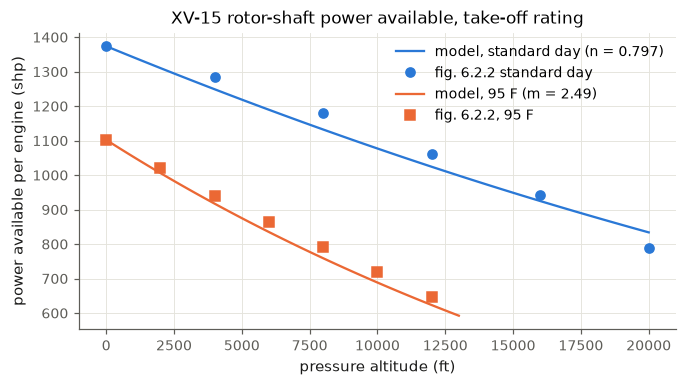

In [24]:
pred = []
for h, m in zip(hot.altitude_hover_m, hot.mass_hover_kg):
    p = hover_mass_hot_kg(hot_atmosphere(h), fm, model)
    pred.append(p / m - 1)
    tag = "  (extrapolated lapse)" if h > hot.altitude_power_data_max_m + 1 else ""
    print(f"hover {h / u.foot:6.0f} ft: figure {lb(m):6.0f} lb, predicted {lb(p):6.0f} lb ({p / m - 1:+.1%}){tag}")
check("hot-day hover predictions within -2.6 % to -1.5 % up to 12,000 ft", all(-0.027 < e < -0.014 for e in pred[:7]))
check("hot-day hover prediction +4.4 % at 18,000 ft", round(pred[-1], 3) == 0.044)

fig, ax = plt.subplots(figsize=(7, 3.5))
hs = np.linspace(0, 20000, 81)
ax.plot(hs, [float(xv15_engine(n).power_available_W(asb.Atmosphere(altitude=h * u.foot))) / u.hp for h in hs],
        color=blue, label=f"model, standard day (n = {n:.3f})")
ax.plot([h / u.foot for h in data.altitude_power_m], [p / u.hp for p in data.power_available_rotor_W], "o", color=blue,
        label="fig. 6.2.2 standard day")
hh = np.linspace(0, 13000, 53)
ax.plot(hh, [float(xv15_engine_hot(model).power_available_W(hot_atmosphere(h * u.foot))) / u.hp for h in hh],
        color=orange, label=f"model, 95 F (m = {m_exp:.2f})")
ax.plot([h / u.foot for h in hot.altitude_power_m], [p / u.hp for p in hot.power_available_rotor_W], "s", color=orange,
        label="fig. 6.2.2, 95 F")
ax.set_xlabel("pressure altitude (ft)"); ax.set_ylabel("power available per engine (shp)")
ax.set_title("XV-15 rotor-shaft power available, take-off rating"); ax.legend(); plt.show()

The plot shows what the numbers say: the model is a power law in σ, so it is straight in log space and misses the
knee of the real curve; the 95 F offset (the *ratio*) is captured to 0.3 %.

**Gotchas, sections 2-3**
- The engine is on a **rotor-shaft basis** (1,374 shp, not 1,550 shp): transmission and installation losses are
  inside the rating. The Halo uses n and m only, not the 0.887 knockdown.
- FM 0.670 includes everything the actuator disk leaves out (profile power, swirl, tip loss, non-uniform inflow) at
  the XV-15's disk loading. It is calibrated on one point.
- The 95 F hover above 12,000 ft extrapolates the lapse fit; the error grows to +4.4 % at 18,000 ft.

---
## 4. `examples/tiltrotor_wing_calibration.py` and `data/weights/*.csv`

### 4.1 The data files

In [25]:
show_source("data/weights/sources.csv")

# data/weights/sources.csv  lines 1-11
   1  key,citation,url
   2  TMX62407,"NASA TM X-62407 (1975), NASA/Army XV-15 Tilt Rotor Research Aircraft Familiarization Document, sec. 3.1.2, 3.3, 3.4",https://ntrs.nasa.gov/citations/19750016648
   3  ACREE99,"C. W. Acree Jr., R. J. Peyran, W. Johnson, Rotor Design for Whirl Flutter: An Examination of Options for Improving Tiltrotor Aeroelastic Stability Margins, AHS 55th Annual Forum, 1999, table 5",https://rotorcraft.arc.nasa.gov/Publications/files/Acree_AHS99.pdf
   4  TP2004212262,"C. W. Acree Jr., R. J. Peyran, W. Johnson, Rotor Design Options for Improving XV-15 Whirl-Flutter Stability Margins, NASA/TP-2004-212262, appendices C and D",https://ntrs.nasa.gov/api/citations/20040081235/downloads/20040081235.pdf
   5  ACREE02,"C. W. Acree Jr., Rotor Design Options for Improving V-22 Whirl-Mode Stability, AHS 58th Annual Forum, 2002",https://rotorcraft.arc.nasa.gov/Publications/files/Acree_AHSF02.pdf
   6  POPELKA95,"D. Popelka, D. Lindsay, T

In [26]:
show_source("data/weights/tiltrotor_wing_reference.csv")

# data/weights/tiltrotor_wing_reference.csv  lines 1-56
   1  aircraft,item,value,unit,source,note
   2  xv15,wing_group,873,lb,TMX62407,Nov 1974 group weight statement sec. 3.1.2 (the Tier 10a calibration target)
   3  xv15,wing_total_breakdown,946,lb,ACREE99,Table 5 wing structural comparison (Chappell-Peyran methodology level)
   4  xv15,wing_torque_box,567,lb,ACREE99,Table 5
   5  xv15,wing_spars,52,lb,ACREE99,Table 5
   6  xv15,wing_control_surfaces,97,lb,ACREE99,Table 5
   7  xv15,wing_fairings,108,lb,ACREE99,Table 5
   8  xv15,wing_fittings_other,122,lb,ACREE99,Table 5
   9  xv15,stiffness_beam,3.70e9,lb-in2,ACREE99,Table 5 (also TP-2004-212262 table 1)
  10  xv15,stiffness_chord,1.12e10,lb-in2,ACREE99,Table 5
  11  xv15,stiffness_torsion,2.80e9,lb-in2,ACREE99,Table 5
  12  xv15,modulus_torque_box,10.0e6,psi,ACREE99,Table 5 aluminium
  13  xv15,modulus_spar,10.0e6,psi,ACREE99,Table 5 aluminium
  14  xv15,modulus_shear_torque_box,3.8e6,psi,ACREE99,Table 5 aluminium
  15  xv15,den

- **`sources.csv` L1-11:** key, full citation, URL. Ten sources: the XV-15 familiarization document, three Acree
  et al. whirl-flutter papers (XV-15 wing breakdown and stiffness, the stick model, V-22 rotor speeds), Popelka
  1995 (V-22 composite wing weight), Harris 2015 vol. III (Bell D266 statement, FSD V-22 weights), the CTR30
  report (V-22 wing geometry), NDARC theory, the T406 rating and the JVX rotor data.
- **`tiltrotor_wing_reference.csv`:** one row per (aircraft, item) with value, **unit**, source key and note. Units
  are the source's (lb, ft, psi, lb-in², rpm, Hz); the code converts at use. "lb-in2" stiffness is lbf·in², converted
  by `stiffness_lb_in2` (L36 below).
  - **L2-29 XV-15:** group 873 lb; the Acree table 5 wing breakdown (box 567, spars 52, control surfaces 97,
    fairings 108, fittings 122: total 946 lb at "methodology level", not the 873 lb statement); EI_beam 3.70e9,
    EI_chord 1.12e10, GJ 2.80e9 lb-in²; aluminium properties; geometry; stick-model masses and modes.
  - **L30-38, L55-56 V-22:** FSD wing 2,470 lb (scope of fold/rotate items not stated), 47,500 lb design gross,
    23 % t/c, CTR30 span and area, 19 ft rotor, airplane-mode 333 rpm, derived hover tip speed, T406 6,150 shp,
    solidity 0.105.
  - **L39-54 Bell D266:** the full 1968 MIL-STD-451 statement (wing 1,886, rotor 2,439 lb, ...), geometry, rotor
    speeds and T64 power.
  - Rows L2-3, L16, L23-29, L32, L41-44 and L46-47 are recorded but not read by the code: the XV-15 group,
    stick-model masses and modes are hardcoded in `Xv15Reference` instead (documentation of the source).

### 4.2 Header, loader, section calibration

In [27]:
show_source("examples/tiltrotor_wing_calibration.py", 1, 95)

# examples/tiltrotor_wing_calibration.py  lines 1-95
   1  """AFDD tiltrotor wing: XV-15 section calibration and cross-checks on the V-22 and Bell D266 (Tier 20, plan 024).
   2  
   3  Data: `data/weights/tiltrotor_wing_reference.csv` (values with a source key per
   4  row) and `data/weights/sources.csv` (citations).
   5  
   6  1. XV-15 section calibration. The published XV-15 wing stiffness, materials and
   7     component weights (Acree et al. 1999, table 5) fix NDARC's torque-box
   8     structural efficiency, the spar-taper correction, the fairing and
   9     control-surface unit masses and the fittings fraction. These are the
  10     `TiltrotorWingMassModel` defaults.
  11  2. XV-15 wing group: the model from the published wing modes and tip masses
  12     against the 873 lb group statement gives `Xv15MassFactors.wing_tiltrotor`.
  13  3. Cross-checks with no further fitting:
  14     - V-22 FSD wing (about 2,470 lb, Popelka et al. 1995), composite;
  15     - Bell D266 w

- **L1-20 docstring.** Three steps: (1) the XV-15 section data fix NDARC's section constants (the model defaults);
  (2) the model driven by the XV-15's *modes* against the 873 lb group gives `wing_tiltrotor`; (3) V-22 and D266
  cross-checks with no further fitting. No public V-22 or AW609 group statements exist (D024).
- **L21-33 imports.** `replace` (L23) and `Xv15MassFactors` (L33) are imported and never used (Findings).
- **L35** the CSV path from the file location (`parents[1]` is the repo root), so it works from any cwd.
- **L39-42 `load_reference_data`.** `{(aircraft, item): float}`; units stay those of the CSV.
- **L45-52 `WingSectionCalibration`**: the six constants.
- **L55-95 `xv15_section_calibration`.** Inverts NDARC's section equations on the published XV-15 wing. NDARC's
  ideal section: a torque box of wall area A (chord c_tb = w c, depth t), spar caps of area A_sp:
  - **L65-69** span = torque-box span 32.17 ft (rotor to rotor), mean chord c = S/b, t = τc, c_tb = 0.45 c (assumed;
    not published).
  - **L73-74** NDARC form factors F_B, F_C, F_T, F_VH (`afdd.py` L98-109): curve fits that relate the airfoil and box
    to the ideal shapes.
  - **L75 torque box from the published GJ:**

$$GJ = G\,F_T\,A_{tb}\,\frac{t^2}{4}\;\Rightarrow\; A_{tb} = \frac{4\,GJ}{G\,F_T\,t^2}$$

  - **L76-78 chord caps:** what the box does not provide of EI_chord, `max(0, ·)`, over E_sp c_tb²/4.
  - **L79-82 beam caps:** EI_beam minus the box's E F_B A t²/4 minus the chord caps' contribution (F_VH factor),
    over E_sp t²/4.
  - **L83-85** control-surface area (flaps + flaperons, 31.2 ft²) and fairing area = (b − attachment width) c
    (1 − w) − A_cs: the aft part of the wing outside the box and outside the body.
  - **L86-87** fittings as a ratio of the rest of the wing.
  - **L88-95** the constants. NDARC writes mass = ρ A b / e_tb, so **e_tb = ρ A_tb b / m_box,actual** (L89); the
    spar correction **C_t = m_spars / (ρ A_caps b)** (L90-91); unit masses = published mass / area; the fittings
    fraction f = r/(1 + r) so that `afdd.py` L218 recovers r = f/(1 − f).

In [28]:
from examples.tiltrotor_wing_calibration import (d266_rotor_implied_solidity, d266_wing_check, load_reference_data,
                                                 v22_wing_check, xv15_frequency_stiffness_ratios, xv15_section_calibration)
from aircraft_closure.vehicle.surfaces import TiltrotorWingMassModel
ref_data = load_reference_data()
print(len(ref_data), "rows;", "xv15 wing_torque_box =", ref_data[("xv15", "wing_torque_box")], "lb")
section = xv15_section_calibration(data=ref_data)
defaults = TiltrotorWingMassModel(mass_tip_kg=0, radius_gyration_pylon_m=0, speed_rotor_design_rad_s=1, width_fuselage_m=0)
for f in fields(section):
    print(f"{f.name:<34}{float(getattr(section, f.name)):9.4f}   model default {getattr(defaults, f.name):7.3f}")
check("section calibration = TiltrotorWingMassModel defaults (rounded, within 0.25 %)",
      all(abs(float(getattr(section, f.name)) / getattr(defaults, f.name) - 1) < 2.5e-3 for f in fields(section)))

55 rows; xv15 wing_torque_box = 567.0 lb
efficiency_torque_box                0.5826   model default   0.583
correction_spar_stiffness            0.5262   model default   0.526
unit_mass_fairing_kg_m2             10.9248   model default  10.920
unit_mass_control_surfaces_kg_m2    15.1793   model default  15.180
fraction_fittings                    0.1290   model default   0.129
fraction_area_control_surfaces       0.1846   model default   0.185
PASS  section calibration = TiltrotorWingMassModel defaults (rounded, within 0.25 %)


### 4.3 The checks: V-22, D266, implied solidity, stiffness ratios

In [29]:
show_source("examples/tiltrotor_wing_calibration.py", 98, 149)

# examples/tiltrotor_wing_calibration.py  lines 98-149
  98  @dataclass(frozen=True)
  99  class WingCheck:
 100      aircraft: str
 101      mass_actual_kg: float
 102      mass_predicted_kg: float              # model x 1 (uncalibrated)
 103      mass_predicted_calibrated_kg: float   # model x the XV-15 factor `wing_tiltrotor`
 104      masses: object                        # afdd.TiltrotorWingMasses
 105      mass_tip_kg: float
 106      note: str
 107  
 108  
 109  def _evaluate(model, span_m, area_m2, mass_design_kg):
 110      wing = Wing(area_m2=area_m2, aspect_ratio=span_m**2 / area_m2, mass_model=model)
 111      return model.masses(wing, StructuralDesignCondition(mass_design_kg=mass_design_kg))
 112  
 113  
 114  def v22_wing_check(factors=None, data=None):
 115      """V-22 FSD wing from the XV-15-calibrated AFDD model, graphite epoxy, XV-15 frequency placement.
 116  
 117      Tip mass is a framework model-chain estimate (no public V-22 nacelle weights): AFDD82 rotor (si

- **L98-106 `WingCheck`**: actual, model × 1, model × `wing_tiltrotor`, the itemised masses, the tip mass, a note.
- **L109-111 `_evaluate`.** A `Wing` with AR = b²/S and the mass model; the condition carries only the design mass
  (the AFDD wing reads only `mass_design_kg` from it: the jump take-off load and the tip-mass fraction).
- **L114-149 `v22_wing_check`.** The tip mass is not published, so it is built from the framework's own chain, each
  term times its XV-15 factor:
  - L128 blade chord from solidity: σ = N c / (π R) → c = σ π R / 3;
  - L130 AFDD82 rotor (coning 1.55/rev assumed as XV-15) per rotor;
  - L131 regression engine at 6,150 shp;
  - L132-135 AFDD82 engine section with the nacelle wetted area scaled by R² from the XV-15's 95 ft² (assumed),
    per side (`/ 2`);
  - L136-137 AFDD83 drive (rotor speed = hover tip speed / R = 396 rpm; 15,000 rpm engine assumed);
  - L138 tip mass = rotor + engine + nacelle + **a quarter of the drive** (half the drive at the tips, per side).
  - L139-145 model: pylon gyration 0.222 R (XV-15 ratio), airplane-mode 333 rpm, fuselage width 7.9 ft (assumed),
    **XV-15 mode placement** in per rev, 23 % t/c, **graphite epoxy** (Acree table: E_box 9e6, E_spar 18e6 psi,
    0.06 lb/in³). Fold fraction stays 0: the source does not state whether fold/rotate is in the 2,470 lb.

In [30]:
show_source("examples/tiltrotor_wing_calibration.py", 152, 216)

# examples/tiltrotor_wing_calibration.py  lines 152-216
 152  def d266_wing_check(factors=None, data=None, thickness_to_chord=0.23):
 153      """Bell D266 wing group (1968 design statement): aluminium, XV-15 frequency placement at the 297 rpm maximum
 154      airplane-mode rotor speed. Not published, assumed: t/c 0.23, fuselage width 6.5 ft (5.5 ft cargo bay plus
 155      structure), and half the AFDD83 drive system at the tips (proprotor gearboxes; the engines sit inboard).
 156      Tip mass otherwise from the statement: half the rotor and nacelle groups."""
 157      data = data if data is not None else load_reference_data()
 158      factors = factors if factors is not None else calibration_factors()
 159      d = lambda item: data[("d266", item)]
 160      radius_m = d("radius_rotor") * u.foot
 161      mass_drive_kg = factors.transmission * afdd.mass_gearbox_rotor_shaft_afdd83_kg(
 162          2 * d("power_engine") * u.hp, d("speed_rotor_hover") * u.rpm, 13600 * u.rpm, 3, 0.6

- **L152-174 `d266_wing_check`.** Aluminium, t/c 0.23 and fuselage width 6.5 ft assumed; design rotor speed = the
  297 rpm *maximum* airplane-mode speed (the frequency placement must hold at the fastest rotor). Tip mass from the
  statement itself: half the rotor and nacelle groups (the D266 engines sit inboard) plus a quarter of the AFDD83
  drive (13,600 rpm assumed).
- **L177-193 `d266_rotor_implied_solidity`.** The D266 blade chord is not public, so the rotor model is checked
  backwards: one Opti equality finds the solidity at which AFDD82 × the XV-15 rotor factor gives the 2,439 lb rotor
  group. Judged against typical proprotors (0.08-0.11).
- **L196-205 `xv15_frequency_stiffness_ratios`.** Drives the XV-15 wing model with the published modes and compares
  the realized stiffness with the published stiffness. Span = sqrt(S · AR). L199 is a local import of a function
  that could sit in the top-level import (L33); no cycle requires it.
- **L208-216 `__main__`.**

In [31]:
stiff = xv15_frequency_stiffness_ratios()
print("model / published stiffness (torsion, beam, chord):", tuple(round(x, 3) for x in stiff))
check("frequency-driven stiffness is 0.57 / 0.58 / 0.62 of published", tuple(round(x, 2) for x in stiff) == (0.57, 0.58, 0.62))

wing = build_xv15_aircraft(r, Xv15MassFactors(), mass_engine_kg, "afdd_tiltrotor").wing
m_xv = wing.mass_model.masses(wing, design_condition(r.mass_design_kg, r))
for f in fields(m_xv):
    if f.name.startswith("mass_"):
        print(f"  {f.name:<26}{lb(float(getattr(m_xv, f.name))):7.1f} lb")
print(f"  total x 1 {lb(float(m_xv.total())):.0f} lb; x {factors.wing_tiltrotor:.3f} = "
      f"{lb(float(m_xv.total())) * factors.wing_tiltrotor:.0f} lb (statement 873)")
check("box mass / 567 lb = torsion stiffness ratio (box mass is linear in GJ)",
      abs(lb(float(m_xv.mass_torque_box_kg)) / 567 - stiff[0]) < 2e-3)
check("fairings and control surfaces reproduce 108 and 97 lb (same geometry as the calibration)",
      abs(lb(float(m_xv.mass_fairing_kg)) - 108) < 0.5 and abs(lb(float(m_xv.mass_control_surfaces_kg)) - 97) < 0.5)

model / published stiffness (torsion, beam, chord): (0.574, 0.585, 0.623)
PASS  frequency-driven stiffness is 0.57 / 0.58 / 0.62 of published
  mass_torque_box_kg          325.2 lb
  mass_spar_stiffness_kg       24.4 lb
  mass_spar_jump_kg            18.2 lb
  mass_fairing_kg             107.8 lb
  mass_control_surfaces_kg     97.2 lb
  mass_fittings_kg             84.8 lb
  mass_fold_kg                  0.0 lb
  total x 1 658 lb; x 1.327 = 873 lb (statement 873)
PASS  box mass / 567 lb = torsion stiffness ratio (box mass is linear in GJ)
PASS  fairings and control surfaces reproduce 108 and 97 lb (same geometry as the calibration)


This is the chain behind `wing_tiltrotor` = 1.327. The section constants were fitted on the **published stiffness**.
Driven by the **published modes**, NDARC's single-mode relations (a tip mass on a massless beam) need only 57 % of
the published torsion stiffness, because they ignore the wing's own inertia and the root flexibility. The box comes
out at 57 % of 567 lb, the wing at 658 lb, and the factor restores 873 lb. In the Halo the same frequency placement is
used, so the factor carries the same physics gap (D024).

In [32]:
checks_wing = (v22_wing_check(factors, ref_data), d266_wing_check(factors, ref_data))
for c in checks_wing:
    err = c.mass_predicted_calibrated_kg / c.mass_actual_kg - 1
    print(f"{c.aircraft:<10} actual {lb(c.mass_actual_kg):6,.0f} lb | model x1 {lb(c.mass_predicted_kg):6,.0f} | "
          f"x {factors.wing_tiltrotor:.3f} {lb(c.mass_predicted_calibrated_kg):6,.0f} lb ({err:+.0%}) | tip {lb(c.mass_tip_kg):5,.0f} lb")
v22, d266 = checks_wing
check("V-22 FSD wing -18 % (2,023 vs 2,470 lb)", round(lb(v22.mass_predicted_calibrated_kg)) == 2023
      and round(v22.mass_predicted_calibrated_kg / v22.mass_actual_kg - 1, 2) == -0.18)
check("Bell D266 wing -2 % (1,840 vs 1,886 lb)", round(lb(d266.mass_predicted_calibrated_kg)) == 1840
      and round(d266.mass_predicted_calibrated_kg / d266.mass_actual_kg - 1, 2) == -0.02)
sol = d266_rotor_implied_solidity(factors, ref_data)
print(f"D266 implied solidity {sol:.3f} (typical proprotors 0.08-0.11)")
check("D266 implied solidity 0.062, below the typical range: the calibrated rotor model is heavy there",
      round(sol, 3) == 0.062)

V-22 FSD   actual  2,470 lb | model x1  1,524 | x 1.327  2,023 lb (-18%) | tip 6,482 lb
Bell D266  actual  1,886 lb | model x1  1,386 | x 1.327  1,840 lb (-2%) | tip 2,117 lb
PASS  V-22 FSD wing -18 % (2,023 vs 2,470 lb)
PASS  Bell D266 wing -2 % (1,840 vs 1,886 lb)
D266 implied solidity 0.062 (typical proprotors 0.08-0.11)
PASS  D266 implied solidity 0.062, below the typical range: the calibrated rotor model is heavy there


Reading the cross-checks: the D266 (aluminium, same frequency placement, tip mass from its own statement) lands at
−2 %. The V-22 is −18 %, with two soft inputs: a framework-estimated tip mass (6,482 lb per side) and an unknown
fold/rotate scope. The rotor check says the XV-15 rotor factor would be heavy for the D266. D024 reports these and
changes nothing.

**Gotchas, section 4**
- Model defaults are rounded copies of the calibration (0.583 vs 0.5826, ...), not computed at import. If the CSV
  changes, the defaults do not follow; the test `section calibration = model defaults` is the guard.
- The torque-box chord ratio 0.45 is assumed and drives e_tb and C_t. Notebook 05 shows the sensitivity.
- The 946 lb Acree breakdown and the 873 lb statement differ in scope; the section constants use the breakdown, the
  group factor uses the statement.

---
## 5. `examples/halo_oew_uncertainty.py`

### 5.1 Docstring, maturity levels, the item table

In [33]:
show_source("examples/halo_oew_uncertainty.py", 1, 101)

# examples/halo_oew_uncertainty.py  lines 1-101
   1  """Empty-weight (OEW) prediction of the sized Halo baseline: growth allowance and uncertainty, item by item.
   2  
   3  Each item of the empty-weight build-up carries two separate quantities:
   4  
   5  - **Growth allowance** (`maturity_levels`): the growth expected as the design matures, set by how mature the item's
   6    weight is, following the structure of AIAA S-120A / SAWE mass-growth practice (the percentages are program
   7    defaults, to be set by the weights team). It shifts the prediction: predicted OEW = basic OEW + sum of the
   8    allowances.
   9  - **Uncertainty**: a one-sigma spread that reflects how the item's mass is estimated. Catalogue hardware is tight;
  10    calibrated handbook groups (AFDD, Raymer with XV-15 factors) carry about +/-15 % at 95 % confidence, widened where
  11    the calibration is weakest; lightly modelled items are wide.
  12  
  13  Items are independent and normally distributed,

- **L1-22 docstring.** Two separate quantities per item. **Growth allowance** is a *bias*: weight expected to appear
  as the design matures (AIAA S-120A / SAWE structure; the percentages are program defaults). **Uncertainty** is a
  *spread*: how good the estimating method is. Items are independent normals, so

$$\mu_{OEW} = \sum_i (1+g_i)\,W_i,\qquad \sigma_{OEW} = \sqrt{\sum_i (s_i W_i)^2}$$

  Held at fixed take-off weight: no re-sizing growth. Correlated errors would widen σ. The target is a
  not-to-exceed OEW (default: today's basic OEW); the 95 % and 99 % values are one-sided quantiles.
- **L23-28 imports**: plain numpy (no symbolic use here), units.
- **L30** plot colours; `grey` is never used. **L31** one-sided standard-normal quantiles z_95 = 1.6449,
  z_99 = 2.3263.
- **L34-40 `maturity_levels`**: 2 / 5 / 8 / 10 / 15 %.
- **L43-54 `OewItem`**; `growth_fraction` looks the maturity up (a typo in a maturity raises `KeyError`).
- **L57-88 `item_definitions`.** 16 items, each (label, group, keys in the sizing result, maturity, σ fraction, basis).
  Keys `pt:` are powertrain instances (`sizing.powertrain_masses_kg`), the others airframe components
  (`sizing.component_masses_kg`). The aggregate `"powertrain"` component key is deliberately not used (it would
  double count). σ follows the method: 2.5 % for off-the-shelf turboshafts, 5 % for catalogue machines, 7.5-15 % for
  calibrated handbook groups (about ±15 % at 95 %), 20 % for the protection estimate. The basis strings hardcode
  "x 1.33" and "x 1.70": they describe the current factors, they are not read from them.
- **L91-101 `oew_items`.** Sums the keys per item (`.get(k, 0.0)`: a missing instance counts as zero, so the table
  works for architectures without, say, a heat exchanger) and **checks the items sum to the sized OEW within 1 kg**
  (L98-100). Any component the definitions forget makes the function raise rather than silently drop mass.

In [34]:
from examples.halo_oew_uncertainty import (item_definitions, markdown_table, maturity_levels, oew_distribution, oew_items,
                                           plot_distribution, probability_at_most, run, z_95, z_99)
ref = baseline()
items = oew_items(ref)
print(f"{len(items)} items, sum {lb(sum(i.mass_kg for i in items)):,.1f} lb; sized OEW {lb(ref.mass_empty_kg):,.1f} lb")
print("component keys not mapped to an item:",
      sorted(set(dict(ref.component_masses_kg)) - {k for d in item_definitions for k in d[2] if not k.startswith("pt:")}))
check("items sum to the sized OEW within 1 kg", abs(sum(i.mass_kg for i in items) - ref.mass_empty_kg) < 1.0)
broken = SimpleNamespace(component_masses_kg=tuple((k, v) for k, v in ref.component_masses_kg if k != "nacelles"),
                         powertrain_masses_kg=ref.powertrain_masses_kg, mass_empty_kg=ref.mass_empty_kg)
try:
    oew_items(broken)
except ValueError as error:
    print("drop the nacelles ->", error)
check("one-sided quantiles: Phi(z_95) = 0.95, Phi(z_99) = 0.99",
      abs(0.5 * (1 + math.erf(z_95 / math.sqrt(2))) - 0.95) < 1e-4 and abs(0.5 * (1 + math.erf(z_99 / math.sqrt(2))) - 0.99) < 1e-4)

16 items, sum 11,130.3 lb; sized OEW 11,130.3 lb
component keys not mapped to an item: ['drive_shaft', 'fuel', 'payload', 'powertrain']
PASS  items sum to the sized OEW within 1 kg
drop the nacelles -> items sum to 4853.8 kg, OEW is 5048.6 kg
PASS  one-sided quantiles: Phi(z_95) = 0.95, Phi(z_99) = 0.99


`payload`, `fuel` and the `powertrain` aggregate are excluded on purpose. `drive_shaft` is not mapped either: the
Halo has no interconnect shaft (0 kg). A design with one would trip the L98-100 check, which is the intended
failure mode.

### 5.2 The distribution, the table, the probability

In [35]:
show_source("examples/halo_oew_uncertainty.py", 104, 153)

# examples/halo_oew_uncertainty.py  lines 104-153
 104  @dataclass(frozen=True)
 105  class OewDistribution:
 106      basic_lb: float                      # sum of the basic item weights (the sized OEW)
 107      growth_lb: float                     # sum of the growth allowances
 108      sigma_lb: float                      # root sum of squares of the item uncertainties
 109  
 110      @property
 111      def mean_lb(self):
 112          """Predicted OEW: basic weight plus growth allowance."""
 113          return self.basic_lb + self.growth_lb
 114  
 115      @property
 116      def value_95_lb(self):
 117          return self.mean_lb + z_95 * self.sigma_lb
 118  
 119      @property
 120      def value_99_lb(self):
 121          return self.mean_lb + z_99 * self.sigma_lb
 122  
 123  
 124  def oew_distribution(items):
 125      basic_lb = sum(item.mass_kg for item in items) / u.lbm
 126      growth_lb = sum(item.growth_fraction * item.mass_kg for item in items) / u.lbm
 127   

- **L104-121 `OewDistribution`**: basic, growth and σ in lb. `mean_lb` = basic + growth; `value_95_lb`,
  `value_99_lb` = mean + z σ.
- **L124-128 `oew_distribution`**: the two sums and the root sum of squares, converted to lb.
- **L131-147 `markdown_table`**: powertrain first, then airframe, each sorted by mass; the bold OEW row gives the
  overall growth % and σ %. This is the generator of the README table.
- **L150-153 `probability_at_most`**: the normal CDF through `math.erf`, Φ(z) = ½ (1 + erf(z/√2)).

In [36]:
d = oew_distribution(items)
print(f"basic {d.basic_lb:,.0f} lb, growth {d.growth_lb:,.0f} lb ({100 * d.growth_lb / d.basic_lb:.1f} %), "
      f"predicted {d.mean_lb:,.0f} lb, sigma {d.sigma_lb:,.0f} lb ({100 * d.sigma_lb / d.basic_lb:.1f} %)")
print(f"95 % {d.value_95_lb:,.0f} lb, 99 % {d.value_99_lb:,.0f} lb ({d.value_99_lb - d.basic_lb:,.0f} lb over the basic OEW); "
      f"P(OEW <= basic) = {100 * probability_at_most(d, d.basic_lb):.3f} %")
check("README: basic 11,130, growth 962 (8.6 %), predicted 12,092, sigma 280 (2.5 %), 99 % is 1,613 lb over",
      [round(x) for x in (d.basic_lb, d.growth_lb, d.mean_lb, d.sigma_lb, d.value_99_lb - d.basic_lb)]
      == [11130, 962, 12092, 280, 1613] and round(100 * d.growth_lb / d.basic_lb, 1) == 8.6)

readme = (repo_root / "README.md").read_text().splitlines()
start = next(i for i, line in enumerate(readme) if line.startswith("| Item | Basic weight (lb)"))
end = next(i for i in range(start, len(readme)) if readme[i].startswith("| **OEW**"))
table = markdown_table(items, d).splitlines()
check("markdown_table reproduces the README OEW table line for line", table == readme[start:end + 1])
sigma_correlated = sum(i.sigma_fraction * i.mass_kg for i in items) / u.lbm
print(f"fully correlated errors: sigma {sigma_correlated:,.0f} lb against {d.sigma_lb:,.0f} lb independent")

basic 11,130 lb, growth 962 lb (8.6 %), predicted 12,092 lb, sigma 280 lb (2.5 %)
95 % 12,552 lb, 99 % 12,743 lb (1,613 lb over the basic OEW); P(OEW <= basic) = 0.030 %
PASS  README: basic 11,130, growth 962 (8.6 %), predicted 12,092, sigma 280 (2.5 %), 99 % is 1,613 lb over
PASS  markdown_table reproduces the README OEW table line for line
fully correlated errors: sigma 953 lb against 280 lb independent


The growth allowance (962 lb) is more than three times σ (280 lb): the prediction is dominated by the bias, not the
spread. σ is small (2.5 %) because 16 independent items average out; if every Raymer group were biased the same way
(fully correlated), σ would be the linear sum, about three times larger. The README says so.

### 5.3 The plot and `run`

In [37]:
show_source("examples/halo_oew_uncertainty.py", 156, 226)

# examples/halo_oew_uncertainty.py  lines 156-226
 156  def plot_distribution(distribution, path, title, target_lb=None):
 157      """Predicted OEW density with the target and the 95 % and 99 % values; shades the chance of meeting the target."""
 158      import matplotlib
 159      matplotlib.use("Agg")
 160      import matplotlib.pyplot as plt
 161      d = distribution
 162      target_lb = d.basic_lb if target_lb is None else target_lb
 163      low_lb, high_lb = min(target_lb, d.mean_lb - 4 * d.sigma_lb), d.mean_lb + 4 * d.sigma_lb
 164      weight_lb = numpy.linspace(low_lb - 0.5 * d.sigma_lb, high_lb, 700)
 165      pdf = numpy.exp(-0.5 * ((weight_lb - d.mean_lb) / d.sigma_lb) ** 2) / (d.sigma_lb * numpy.sqrt(2 * numpy.pi))
 166      chance = probability_at_most(d, target_lb)
 167      fig, ax = plt.subplots(figsize=(8.5, 4.8))
 168      ax.plot(weight_lb, pdf, color=blue, lw=2.2)
 169      ax.fill_between(weight_lb, pdf, where=weight_lb <= target_lb, color=blue, alpha=0.25, lw

- **L156-200 `plot_distribution`.** The normal density over [min(target, μ − 4σ) − σ/2, μ + 4σ]; shades the area left
  of the target (the chance of meeting it); if the 99 % value is above the target, a double arrow shows the gap (the
  design rule: the 99 % value must be at or below the not-to-exceed target, L172). Vertical lines for target,
  predicted, 95 % and 99 %. **L158-159 call `matplotlib.use("Agg")`**: inside a notebook this switches the backend
  away from inline, so later `plt.show()` calls display nothing until the backend is restored (done below).
- **L203-222 `run`.** Solves the baseline sizing only when `sizing is None` (L204-206, a full sizing); otherwise uses
  the result given. Writes the PNG and the markdown table into `directory` and prints the summary.
- **L225-226** `python -m examples.halo_oew_uncertainty` sizes the baseline and writes `output/oew/`.

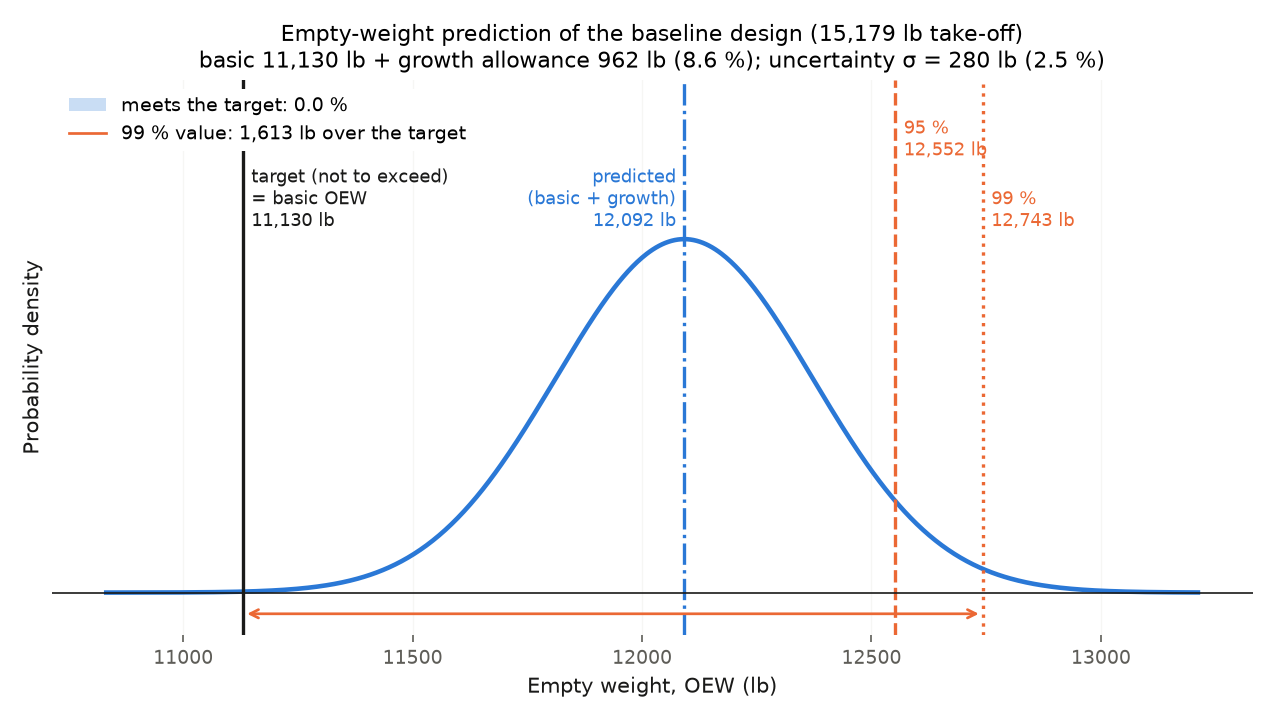

PASS  plot_distribution leaves matplotlib on the Agg backend (restored above)


In [38]:
import tempfile
import matplotlib
from IPython.display import Image, display
with tempfile.TemporaryDirectory() as folder:
    import contextlib, io
    with contextlib.redirect_stdout(io.StringIO()):
        run(ref, directory=folder)                     # the cached baseline: no sizing solve
    backend_ok = matplotlib.get_backend().lower() == "agg"
    display(Image(filename=f"{folder}/oew_distribution.png", width=640))
matplotlib.use("module://matplotlib_inline.backend_inline")   # undo L159 for the rest of the notebook
apply_style()
check("plot_distribution leaves matplotlib on the Agg backend (restored above)", backend_ok)

**Gotchas, section 5**
- The spread is at **fixed take-off weight**. A heavier empty weight re-sizes the aircraft (growth factor about 2.9
  in the Halo), so the take-off consequence of +962 lb OEW is about three times larger.
- Independence is an assumption that narrows σ; correlated calibration errors widen it.
- The percentages are program defaults for a weights team to set, not data.

---
## 6. `examples/halo_design_space.py` (explained, not run)

### 6.1 Docstring and architecture enumeration

In [39]:
show_source("examples/halo_design_space.py", 1, 55)

# examples/halo_design_space.py  lines 1-55
   1  """Tier 22 (plan 029): design-space practice around the Halo sizing solve.
   2  
   3  * `enumerate_architectures`: a full-factorial enumeration over discrete choices that already exist as
   4    `HaloAssumptions` flags. Each combination is a separate coupled solve through the starting-point strategy;
   5    a discrete trade, not a loop.
   6  * `sensitivity_study`: one-at-a-time sensitivity of a sized design to uncertain inputs (assumption fields or
   7    XV-15 calibration factors) scaled by 1 +/- a fraction, as tornado data. Each case runs the starting-point
   8    strategy with the base design as its first start.
   9  
  10  Both take the aerodynamics model from the assumptions they are given; with AeroBuildup a solve takes
  11  2-3 minutes, so the notebook runs the larger sweeps with `aerodynamics_model="scholz"` (about 1 % in mass from
  12  the build-up, plan 025) and says so.
  13  """
  14  import itertools
  15  import 

- **L1-13 docstring.** Two tools around the sizing (Tier 22, D029): a full-factorial **enumeration** of discrete
  choices that already exist as `HaloAssumptions` flags, and a one-at-a-time **sensitivity** study. Each case is a
  separate coupled solve. With AeroBuildup a solve takes 2-3 minutes, so sweeps run with Scholz aerodynamics (about
  1 % in mass, D025).
- **L14-21 imports**: `solve_halo_sizing` (with its integer-unit and gear-stage wrappers) and
  `solve_halo_sizing_multistart` (the starting-point strategy alone), `objective_value`, `calibration_factors`.
- **L24-34 `ArchitectureCase`**: settings as ((field, value), ...), the result (None when no start converged), wall
  time, error message; `converged` property.
- **L37-55 `enumerate_architectures`.** `itertools.product` over the option values in dict order (L46). Each
  combination: `replace(assumptions, **settings)` and one `solve_halo_sizing_multistart` (L50-51). **Discrete choices
  stay outside the NLP**: integer structure (lanes, battery model, gear stages on/off) is enumerated, never relaxed
  inside IPOPT. One `cache` dict is shared, so precursor problems (e.g. the Scholz or constant-battery start of
  each case) are solved once for the whole sweep. A failed case is recorded with its message (L53-54), not raised:
  a sweep reports infeasible corners instead of stopping.

The trade this runs: for example `{"battery_model": ("constant", "ecm")}` (the test case; D029 notes the planned
generator step-up pair could not be used because on-shaft generators do not close at 900 kg). Each case is a full
sizing, minutes each.

In [40]:
import itertools
options = {"battery_model": ("constant", "ecm"), "redundancy": (False, True), "gearbox_stages": (False, True)}
order = [tuple(zip(options, values)) for values in itertools.product(*options.values())]
print(f"{len(order)} solves, in this order:")
for settings in order[:4]:
    print("  ", settings)
print("   ...")
check("enumeration size is the product of the option counts", len(order) == 2 * 2 * 2)

8 solves, in this order:
   (('battery_model', 'constant'), ('redundancy', False), ('gearbox_stages', False))
   (('battery_model', 'constant'), ('redundancy', False), ('gearbox_stages', True))
   (('battery_model', 'constant'), ('redundancy', True), ('gearbox_stages', False))
   (('battery_model', 'constant'), ('redundancy', True), ('gearbox_stages', True))
   ...
PASS  enumeration size is the product of the option counts


### 6.2 Sensitivity: inputs, cases, tornado

In [41]:
show_source("examples/halo_design_space.py", 58, 136)

# examples/halo_design_space.py  lines 58-136
  58  @dataclass(frozen=True)
  59  class UncertainInput:
  60      """An uncertain input: a `HaloAssumptions` field (`target` "assumptions") or an `Xv15MassFactors` field
  61      (`target` "factors")."""
  62      label: str
  63      target: str
  64      name: str
  65  
  66  
  67  default_uncertain_inputs = (
  68      UncertainInput("fittings drag area", "assumptions", "drag_area_misc_buildup_m2"),
  69      UncertainInput("cell power-density factor", "assumptions", "factor_power_density_battery"),
  70      UncertainInput("battery capacity at end of life", "assumptions", "factor_capacity_ageing_battery"),
  71      UncertainInput("battery resistance at end of life", "assumptions", "factor_resistance_ageing_battery"),
  72      UncertainInput("machine torque density", "assumptions", "torque_density_Nm_kg"),
  73      UncertainInput("fixed equipment mass", "assumptions", "mass_equipment_kg"),
  74      UncertainInput("wing calibrati

- **L58-64 `UncertainInput`**: a label, a target ("assumptions" or "factors") and a field name.
- **L67-78 `default_uncertain_inputs`**: drag (fittings drag area), battery (power-density factor, end-of-life
  capacity and resistance), machine torque density, fixed equipment mass, and four XV-15 calibration factors (wing,
  rotor, fuselage, powerplant).
- **L81-87 `SensitivityCase`**: label, scale, result, the start that converged.
- **L90-105 `SensitivityStudy.tornado`.** For each case the objective delta against the base (None if it failed),
  collected per label into (low, high) by whether the scale is below 1 (L103), sorted by the largest absolute
  delta (L104-105, None counted as 0).
- **L108-136 `sensitivity_study`.** Factors default to the XV-15 calibration (L116). The base is solved once if not
  given (L117-118, with `solve_halo_sizing`). Each input is scaled by 1 ± fraction (15 % default), on either the
  assumptions or the factors (L122-128, a bad target raises), and re-sized with `initial=base`: the base design is the
  first ("caller") start, so a 15 % perturbation usually converges in one solve from a nearby point. Failures are
  recorded as `result=None`, start "none converged". 10 inputs × 2 scales = 20 sizings.

The trades this answers: which uncertain input moves take-off weight most. RESULTS.md §6 reports the calibration
factors as the largest sensitivities (about ±540 lb each for ±15 %). Below, `tornado` is exercised on stand-in
results (no solve), and each default input is checked to exist.

In [42]:
from examples.halo_design_space import SensitivityCase, SensitivityStudy, UncertainInput, default_uncertain_inputs
from examples.halo_sizing import HaloAssumptions, HaloRequirements, build_halo_aircraft
fake = lambda m: SimpleNamespace(mass_takeoff_kg=m)
study = SensitivityStudy(fake(6000.0), (
    SensitivityCase("battery", 0.85, fake(6050.0)), SensitivityCase("battery", 1.15, fake(5980.0)),
    SensitivityCase("wing", 0.85, fake(5900.0)), SensitivityCase("wing", 1.15, fake(6120.0)),
    SensitivityCase("drag", 0.85, None), SensitivityCase("drag", 1.15, fake(6300.0))))
for row in study.tornado():
    print(row)
check("tornado sorts by the largest |delta| and keeps None for a failed case",
      [r_[0] for r_ in study.tornado()] == ["drag", "wing", "battery"] and study.tornado()[0][1] is None)
a_defaults = HaloAssumptions()
check("every default uncertain input names an existing field",
      all(hasattr(a_defaults if i.target == "assumptions" else factors, i.name) for i in default_uncertain_inputs))

('drag', None, 300.0)
('wing', -100.0, 120.0)
('battery', 50.0, -20.0)
PASS  tornado sorts by the largest |delta| and keeps None for a failed case
PASS  every default uncertain input names an existing field


**Which inputs are live at today's defaults?** A cheap first-order look: rebuild the sized baseline aircraft (fixed
design, no re-sizing) with each mass-type input at +15 % and read the empty-mass change. Inputs that act through
performance (drag, battery) show zero or near zero here by construction; they need the sizing.

In [43]:
a0 = baseline_assumptions()
from aircraft_closure.vehicle.condition import StructuralDesignCondition
cond = StructuralDesignCondition(mass_design_kg=ref.mass_takeoff_kg, load_factor_ultimate=a0.load_factor_ultimate)
def empty_kg(a, f):
    b = build_halo_aircraft(ref.design, HaloRequirements(), a, f).get_mass_breakdown(cond)
    return scalar(b.total().mass) - scalar(b.payload.mass) - scalar(b.fuel.mass)
base_empty = empty_kg(a0, factors)
deltas = {}
for item in default_uncertain_inputs:
    if item.target == "assumptions":
        a1, f1 = replace(a0, **{item.name: getattr(a0, item.name) * 1.15}), factors
    else:
        a1, f1 = a0, replace(factors, **{item.name: getattr(factors, item.name) * 1.15})
    deltas[item.label] = lb(empty_kg(a1, f1) - base_empty)
    print(f"{item.label:<36} +15 %: OEW {deltas[item.label]:+7.1f} lb at fixed design")
print("machine_mass_model =", a0.machine_mass_model, "; mass_factor_fuselage =", a0.mass_factor_fuselage)
check("at the v3.6 defaults the fuselage factor and the torque density do not touch the aircraft",
      deltas["fuselage calibration factor"] == 0.0 and deltas["machine torque density"] == 0.0)
check("the wing factor is live: +15 % adds 15 % of the 899 lb wing", abs(deltas["wing calibration factor"] - 0.15 * 899) < 1.5)

fittings drag area                   +15 %: OEW    +0.0 lb at fixed design
cell power-density factor            +15 %: OEW    +3.5 lb at fixed design
battery capacity at end of life      +15 %: OEW    +0.0 lb at fixed design
battery resistance at end of life    +15 %: OEW    +0.0 lb at fixed design
machine torque density               +15 %: OEW    +0.0 lb at fixed design
fixed equipment mass                 +15 %: OEW   +88.1 lb at fixed design
wing calibration factor              +15 %: OEW  +134.9 lb at fixed design
rotor calibration factor             +15 %: OEW  +239.9 lb at fixed design
fuselage calibration factor          +15 %: OEW    +0.0 lb at fixed design
powerplant calibration factor        +15 %: OEW  +204.2 lb at fixed design
machine_mass_model = units ; mass_factor_fuselage = 1.7
PASS  at the v3.6 defaults the fuselage factor and the torque density do not touch the aircraft
PASS  the wing factor is live: +15 % adds 15 % of the 899 lb wing


Two of the ten default inputs are inert under today's `HaloAssumptions()`: the fuselage factor is overridden by
`mass_factor_fuselage = 1.70` (`halo_sizing.py` L887-888, D037) and the machine torque density is unused with the
unit-built machines (`machine_mass_model = "units"`, D035). The tests run the study on `assumptions_plan027`, where
both are live (it pins `mass_factor_fuselage=None` and torque-density machines). See Findings.

**Gotchas, section 6**
- Each case is a full coupled sizing; a 20-case tornado at AeroBuildup fidelity is about an hour. Use Scholz for
  sweeps and say so.
- One-at-a-time: no interactions, and ±15 % is the same relative step for very different uncertainties.
- `enumerate_architectures` and `sensitivity_study` call `solve_halo_sizing_multistart` directly, which bypasses the
  integer-unit wrapper in `solve_halo_sizing` (L1024-1033). See Findings.

---
## Findings

1. **Unused imports** in `examples/tiltrotor_wing_calibration.py`: `replace` (L23) and `Xv15MassFactors` (L33).
   `ruff --select F401` flags both. Harmless.
2. **Unused constant** `grey` in `examples/halo_oew_uncertainty.py` L30.
3. **Dead data field** `Xv15PowerData.altitude_hover_ceiling_published_m` (`xv15_performance.py` L39): no code reads
   it; the `__main__` print hardcodes "8,650 ft" (L132).
4. **Backend side effect**: `plot_distribution` calls `matplotlib.use("Agg")` (`halo_oew_uncertainty.py` L158-159).
   Called from a notebook, it silently disables inline plots afterwards (shown above).
5. **Inert sensitivity inputs at the current defaults**: `default_uncertain_inputs` (`halo_design_space.py` L72, L76)
   includes `torque_density_Nm_kg` and the `fuselage` factor. With `HaloAssumptions()` (units machines, fuselage
   factor 1.70) neither reaches the mass model, so a default `sensitivity_study()` would spend four sizings and
   report zero deltas for them. Verified above at fixed design.
6. **Integer units bypassed in the design-space tools**: with default assumptions (`machine_mass_model="units"`,
   `integer_units=True`, unit counts None) `solve_halo_sizing` relaxes, rounds and re-solves (`halo_sizing.py`
   L1024-1033), but `enumerate_architectures` (L50) and `sensitivity_study` (L130) call
   `solve_halo_sizing_multistart`, which goes straight to `solve_halo_sizing_once` with relaxed (fractional) unit
   counts (`halo_sizing.py` L1756, L990). The sensitivity base (L118) is an integer-unit design and the cases are
   relaxed, so each delta mixes the input's effect with the rounding effect. The tools predate plan 035; the tests
   use `assumptions_plan027` (torque-density machines), where this does not arise. Passing fixed unit counts (as
   `baseline_assumptions()` does) avoids it. Code reading; not run (full sizings).
7. **Hardcoded basis strings**: the OEW basis column says "x 1.33" and "x 1.70" (`halo_oew_uncertainty.py` L60,
   L64); they will drift if the factors change.
8. **Rounded copies as defaults**: `TiltrotorWingMassModel` defaults (`surfaces.py` L202-208) are rounded copies of
   `xv15_section_calibration()`, not computed from it; a change to the CSV would not propagate (the test guards it).

## Limits / what it can't do

- One complete weight statement (XV-15). The D266 and V-22 check only the wing (and the D266 rotor through an
  implied solidity). Drive systems are checked on the XV-15 only.
- The power checks are hover and lapse; there is no cruise power or drag validation against XV-15 flight data
  (NEXT_STEPS §3).
- The lapse is one exponent in σ and one in T/T_ISA; the knee of the real power curve is not captured.
- The OEW distribution is at fixed take-off weight, items independent.

## What's next (docs/NEXT_STEPS.md)

- §3: calibrate drag and rotor efficiency against XV-15 level-flight power.
- §4: a second complete weights calibration aircraft (fuselage about 2×, flight controls about 4×).
- §7: propagate calibration-factor uncertainty through the sizing to a take-off-weight distribution.

## Review questions

<details><summary>Why does the calibrated XV-15 closure return exactly 13,000 lb, and what does the uncalibrated one tell you?</summary>

The factors are actual / predicted at 13,000 lb, so at that mass the factored groups equal the statement and the
build-up totals 9,076 + 2,434 + 1,490 = 13,000 lb: a fixed point by construction. The uncalibrated closure (11,315 lb,
7,391 lb empty) is what the framework would have predicted for the XV-15's useful load: 13 % light on take-off, 19 %
light on empty weight, mostly from the Raymer wing, fuselage and flight controls.
</details>

<details><summary>Show that the closure multiplier is the growth factor. What value does the XV-15 give and why is the Halo's larger?</summary>

Minimize m s.t. m − W(m) = 0. Adding dW of fixed mass shifts the constraint to m − W = −dW; by the envelope theorem the
optimum changes by |λ| dW. Directly: dm = dW + (∂W/∂m) dm, so GF = 1/(1 − ∂W/∂m). On the calibrated XV-15 at fixed
geometry the three ways agree at 1.17. In the Halo sizing everything re-sizes (battery, engines, wing, rotors), so a
kilogram of fixed mass costs about 2.9 kg of take-off mass (D037).
</details>

<details><summary>How is the figure of merit calibrated and what is validated?</summary>

At the lowest digitized hover point (229 ft, 15,578 lb, 7 % download, UT/W = 1) FM = ideal induced power / power
available, giving 0.670. The other six standard-day points (within 2 % to 10 kft, 3 % at 20 kft), the ceiling (7,141 ft)
and the ten 95 F points (−2.6 % to +4.4 %) are validation; the 95 F set uses no hot-day data except through m, which
is fitted on the power curves, not on hover.
</details>

<details><summary>Why fit m on the ratio of the 95 F and standard-day curves rather than on the 95 F curve alone?</summary>

At equal pressure altitude the ratio is (T/T_ISA)^−(n+m) exactly in the model, and the digitization and the
single-exponent density error are common to both curves. Fitting the ratio cancels the standard-day lapse error (3-4 %)
and isolates the temperature effect: residuals 0.3 %.
</details>

<details><summary>Why is `wing_tiltrotor` 1.327 when the section constants were fitted to the XV-15 wing?</summary>

The constants were fitted to the published *stiffness*. The model is driven by the published *mode frequencies*
through single-mode relations (tip mass on a massless clamped beam). Those relations need only 0.57-0.62 of the real
stiffness, because they ignore the wing's own inertia and root flexibility, so the box comes out at 57 % of 567 lb and the
wing at 658 lb. The factor carries that gap; the Halo uses the same frequency placement and the same factor.
</details>

<details><summary>What do growth allowance and uncertainty each do to the OEW prediction, and why is σ only 2.5 %?</summary>

Growth shifts the mean (+962 lb, 8.6 %, from maturity). Uncertainty sets the spread: σ = sqrt(Σ (s_i W_i)²) = 280 lb.
With 16 independent items the root sum of squares is much smaller than the linear sum (about 3× smaller here); a
common bias across the Raymer groups would undo that. Both are at fixed take-off weight, so re-sizing would multiply
the take-off consequence by the growth factor.
</details>

In [44]:
check_summary()

49 of 49 checks passed
